# Starbucks Customers Return - Data Science Case Study

## Executive Summary

Report phân tích hành vi quay lại của khách hàng Starbucks dựa trên dữ liệu khảo sát gốc và dữ liệu cleaned/encoded. Trọng tâm là kiểm chứng nhóm khách hàng nào thuộc Frequent/Infrequent và các biến nào có pattern rõ trong dataset.

Sau khi đối chiếu số liệu, các pattern rõ hơn nằm ở `spendPurchase`, `membershipCard`, `income`, `timeSpend` và `status`. Một số biến như `location`, `method` và `gender` cần diễn giải thận trọng hơn vì pattern không hoàn toàn nhất quán hoặc chưa đủ cơ sở để xem là yếu tố chính.

Về status, `Employed` là nhóm có số lượng lớn nhất, `Student` là nhóm đáng kể nhưng frequent rate thấp hơn, còn `Self-employed` có frequent rate tương đối cao nhưng số lượng mẫu nhỏ. Recommendation vì vậy tập trung vào membership, tăng giá trị chi tiêu hợp lý và chiến lược riêng cho Student, Employed, Self-employed.

## 1. Business Understanding

**Business question:** “Những nhóm khách hàng nào thường xuyên sử dụng và ít sử dụng dịch vụ Starbucks?”

Mục tiêu phân tích là xác định Frequent/Infrequent customers, kiểm chứng các yếu tố có thể liên quan đến hành vi quay lại, và đề xuất hành động kinh doanh dựa trên số liệu thực tế trong dataset.

## 2. Load Dataset

Load cả 2 dataset trong cùng thư mục:

- `Starbucks satisfactory survey.csv`: dữ liệu khảo sát gốc.
- `Starbucks satisfactory survey encode cleaned.csv`: dữ liệu đã làm sạch, encode và chuẩn hóa tên cột.

In [34]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

RAW_FILE = Path('Starbucks satisfactory survey.csv')
CLEAN_FILE = Path('Starbucks satisfactory survey encode cleaned.csv')

def read_csv_safely(path):
    if not path.exists():
        print(f'File not found: {path}. Please place it in the same folder as this notebook.')
        return pd.DataFrame()
    try:
        return pd.read_csv(path, encoding='utf-8-sig')
    except Exception as exc:
        print(f'Could not read {path}: {exc}')
        return pd.DataFrame()

raw_df = read_csv_safely(RAW_FILE)
clean_df = read_csv_safely(CLEAN_FILE)
print('Raw dataset shape:', raw_df.shape)
print('Cleaned dataset shape:', clean_df.shape)
display(raw_df.head())
display(clean_df.head())

Raw dataset shape: (122, 21)
Cleaned dataset shape: (113, 33)


,Timestamp,1. Your Gender,2. Your Age,3. Are you currently....?,4. What is your annual income?,5. How often do you visit Starbucks?,6. How do you usually enjoy Starbucks?,7. How much time do you normally spend during your visit?,8. The nearest Starbucks's outlet to you is...?,9. Do you have Starbucks membership card?,...,"11. On average, how much would you spend at Starbucks per visit?","12. How would you rate the quality of Starbucks compared to other brands (Coffee Bean, Old Town White Coffee..) to be:",13. How would you rate the price range at Starbucks?,14. How important are sales and promotions in your purchase decision?,"15. How would you rate the ambiance at Starbucks? (lighting, music, etc...)",16. You rate the WiFi quality at Starbucks as..,"17. How would you rate the service at Starbucks? (Promptness, friendliness, etc..)",18. How likely you will choose Starbucks for doing business meetings or hangout with friends?,19. How do you come to hear of promotions at Starbucks? Check all that apply.,20. Will you continue buying at Starbucks?
0,2019/10/01 12:38:43 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Dine in,Between 30 minutes to 1 hour,within 1km,Yes,...,Less than RM20,4,3,5,5,4,4,3,Starbucks Website/Apps;Social Media;Emails;Dea...,Yes
1,2019/10/01 12:38:54 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,1km - 3km,Yes,...,Less than RM20,4,3,4,4,4,5,2,Social Media;In Store displays,Yes
2,2019/10/01 12:38:56 PM GMT+8,Male,From 20 to 29,Employed,"Less than RM25,000",Monthly,Dine in,Between 30 minutes to 1 hour,more than 3km,Yes,...,Less than RM20,4,3,4,4,4,4,3,In Store displays;Billboards,Yes
3,2019/10/01 12:39:08 PM GMT+8,Female,From 20 to 29,Student,"Less than RM25,000",Rarely,Take away,Below 30 minutes,more than 3km,No,...,Less than RM20,2,1,4,3,3,3,3,Through friends and word of mouth,No
4,2019/10/01 12:39:20 PM GMT+8,Male,From 20 to 29,Student,"Less than RM25,000",Monthly,Take away,Between 30 minutes to 1 hour,1km - 3km,No,...,Around RM20 - RM40,3,3,4,2,2,3,3,Starbucks Website/Apps;Social Media,Yes


,Id,gender,age,status,income,visitNo,method,timeSpend,location,membershipCard,...,chooseRate,promoMethodApp,promoMethodSoc,promoMethodEmail,promoMethodDeal,promoMethodFriend,promoMethodDisplay,promoMethodBillboard,promoMethodOthers,loyal
0,1,1,1,0,0,3,0,1,0,0,...,3,1,1,1,1,1,1,1,1,0
1,2,1,1,0,0,3,2,0,1,0,...,2,1,1,1,1,1,1,1,1,0
2,3,0,1,2,0,2,0,1,2,0,...,3,1,1,1,1,1,1,1,1,0
3,4,1,1,0,0,3,2,0,2,1,...,3,1,1,1,1,1,1,1,1,1
4,5,0,1,0,0,2,2,1,1,1,...,3,1,1,1,1,1,1,1,1,0


## 3. Data Understanding

Raw dataset là dữ liệu khảo sát gốc. Cleaned dataset đã chuẩn hóa tên biến, encode nhiều biến phân loại và phù hợp hơn cho EDA. Phần này kiểm tra columns, info, describe, missing values và duplicated rows.

In [35]:
print('Raw columns:')
display(pd.DataFrame({'raw_columns': raw_df.columns}) if not raw_df.empty else pd.DataFrame({'message':['raw_df is empty']}))
print('Cleaned columns:')
display(pd.DataFrame({'cleaned_columns': clean_df.columns}) if not clean_df.empty else pd.DataFrame({'message':['clean_df is empty']}))
if not clean_df.empty:
    clean_df.info()
    display(clean_df.describe(include='all').T)
    display(clean_df.isna().sum().sort_values(ascending=False).to_frame('missing_count'))
    print('Duplicated rows in cleaned dataset:', int(clean_df.duplicated().sum()))
print('Duplicated rows in raw dataset:', int(raw_df.duplicated().sum()) if not raw_df.empty else 'raw_df is empty')

Raw columns:


,raw_columns
0,Timestamp
1,1. Your Gender
2,2. Your Age
3,3. Are you currently....?
4,4. What is your annual income?
5,5. How often do you visit Starbucks?
6,6. How do you usually enjoy Starbucks?
7,7. How much time do you normally spend during...
8,8. The nearest Starbucks's outlet to you is...?
9,9. Do you have Starbucks membership card?


Cleaned columns:


,cleaned_columns
0,Id
1,gender
2,age
3,status
4,income
5,visitNo
6,method
7,timeSpend
8,location
9,membershipCard


<class 'pandas.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Id                      113 non-null    int64
 1   gender                  113 non-null    int64
 2   age                     113 non-null    int64
 3   status                  113 non-null    int64
 4   income                  113 non-null    int64
 5   visitNo                 113 non-null    int64
 6   method                  113 non-null    int64
 7   timeSpend               113 non-null    int64
 8   location                113 non-null    int64
 9   membershipCard          113 non-null    int64
 10  itemPurchaseCoffee      113 non-null    int64
 11  itempurchaseCold        113 non-null    int64
 12  itemPurchasePastries    113 non-null    int64
 13  itemPurchaseJuices      113 non-null    int64
 14  itemPurchaseSandwiches  113 non-null    int64
 15  itemPurchaseOthers      113 non-nu

,count,mean,std,min,25%,50%,75%,max
Id,113.0,60.150442,35.566392,1.0,29.0,60.0,90.0,122.0
gender,113.0,0.522124,0.501735,0.0,0.0,1.0,1.0,1.0
age,113.0,1.185841,0.675445,0.0,1.0,1.0,1.0,3.0
status,113.0,1.221239,0.932877,0.0,0.0,2.0,2.0,3.0
income,113.0,0.761062,1.087874,0.0,0.0,0.0,1.0,4.0
visitNo,113.0,2.557522,0.718854,0.0,2.0,3.0,3.0,3.0
method,113.0,1.070796,0.979402,0.0,0.0,1.0,2.0,5.0
timeSpend,113.0,0.610619,0.849723,0.0,0.0,0.0,1.0,4.0
location,113.0,1.274336,0.804538,0.0,1.0,1.0,2.0,2.0
membershipCard,113.0,0.469027,0.501263,0.0,0.0,0.0,1.0,1.0


,missing_count
Id,0
gender,0
age,0
status,0
income,0
visitNo,0
method,0
timeSpend,0
location,0
membershipCard,0


Duplicated rows in cleaned dataset: 0
Duplicated rows in raw dataset: 0


## 4. Data Cleaning Summary

Dataset cleaned đã được chuẩn hóa tên biến, encode biến phân loại, tách một số câu trả lời nhiều lựa chọn thành nhiều cột, xử lý giá trị không nhất quán như `Never`, `Never buy`, `NA`, và loại bỏ một số bản ghi không phù hợp. Đây là dataset chính để phân tích EDA.

In [36]:
cleaning_comparison = pd.DataFrame({
    'dataset': ['raw_df', 'clean_df'],
    'rows': [raw_df.shape[0], clean_df.shape[0]],
    'columns': [raw_df.shape[1], clean_df.shape[1]],
    'missing_values': [int(raw_df.isna().sum().sum()) if not raw_df.empty else 0, int(clean_df.isna().sum().sum()) if not clean_df.empty else 0],
    'duplicated_rows': [int(raw_df.duplicated().sum()) if not raw_df.empty else 0, int(clean_df.duplicated().sum()) if not clean_df.empty else 0]
})
display(cleaning_comparison)
display(pd.DataFrame({'cleaned_columns': clean_df.columns}) if not clean_df.empty else pd.DataFrame({'message':['clean_df is empty']}))

,dataset,rows,columns,missing_values,duplicated_rows
0,raw_df,122,21,2,0
1,clean_df,113,33,0,0


,cleaned_columns
0,Id
1,gender
2,age
3,status
4,income
5,visitNo
6,method
7,timeSpend
8,location
9,membershipCard


## 5. Feature Engineering

Tạo working dataframe `df`, map label dễ đọc cho các biến encoded và tạo `return_group`: `Daily`, `Weekly`, `Monthly` là Frequent; `Rarely` là Infrequent.

In [37]:
df = clean_df.copy()
label_maps = {
    'gender': {0:'Male',1:'Female','0':'Male','1':'Female'},
    'age': {0:'Below 20',1:'From 20 to 29',2:'From 30 to 39',3:'40 and above','0':'Below 20','1':'From 20 to 29','2':'From 30 to 39','3':'40 and above'},
    'status': {0:'Student',1:'Self-employed',2:'Employed',3:'Housewife','0':'Student','1':'Self-employed','2':'Employed','3':'Housewife'},
    'income': {0:'Less than RM25,000',1:'RM25,000 - RM50,000',2:'RM50,000 - RM100,000',3:'RM100,000 - RM150,000',4:'More than RM150,000','0':'Less than RM25,000','1':'RM25,000 - RM50,000','2':'RM50,000 - RM100,000','3':'RM100,000 - RM150,000','4':'More than RM150,000'},
    'visitNo': {0:'Daily',1:'Weekly',2:'Monthly',3:'Rarely','0':'Daily','1':'Weekly','2':'Monthly','3':'Rarely'},
    'method': {0:'Dine in',1:'Drive-thru',2:'Take away',5:'Other/Unknown','0':'Dine in','1':'Drive-thru','2':'Take away','5':'Other/Unknown'},
    'timeSpend': {0:'Below 30 minutes',1:'30 minutes - 1 hour',2:'1 - 2 hours',3:'More than 3 hours',4:'Other/Unknown','0':'Below 30 minutes','1':'30 minutes - 1 hour','2':'1 - 2 hours','3':'More than 3 hours','4':'Other/Unknown'},
    'location': {0:'within 1km',1:'1km - 3km',2:'more than 3km','0':'within 1km','1':'1km - 3km','2':'more than 3km'},
    'membershipCard': {0:'Yes',1:'No','0':'Yes','1':'No'},
    'spendPurchase': {0:'Zero',1:'Less than RM20',2:'Around RM20 - RM40',3:'More than RM40','0':'Zero','1':'Less than RM20','2':'Around RM20 - RM40','3':'More than RM40'},
    'loyal': {0:'Yes',1:'No','0':'Yes','1':'No'}
}
label_columns = {'visitNo':'visit_label','gender':'gender_label','age':'age_label','status':'status_label','income':'income_label','method':'method_label','timeSpend':'time_label','location':'location_label','membershipCard':'membership_label','spendPurchase':'spend_label','loyal':'loyal_label'}
score_maps = {
    'income': {'Less than RM25,000':0,'RM25,000 - RM50,000':1,'RM50,000 - RM100,000':2,'RM100,000 - RM150,000':3,'More than RM150,000':4,0:0,1:1,2:2,3:3,4:4,'0':0,'1':1,'2':2,'3':3,'4':4},
    'timeSpend': {'Below 30 minutes':0,'30 minutes - 1 hour':1,'1 - 2 hours':2,'More than 3 hours':4,'Other/Unknown':np.nan,0:0,1:1,2:2,3:4,4:np.nan,'0':0,'1':1,'2':2,'3':4,'4':np.nan},
    'location': {'within 1km':0,'1km - 3km':1,'more than 3km':2,0:0,1:1,2:2,'0':0,'1':1,'2':2},
    'membershipCard': {'Yes':1,'No':0,0:1,1:0,'0':1,'1':0},
    'spendPurchase': {'Zero':0,'Less than RM20':1,'Around RM20 - RM40':2,'More than RM40':3,0:0,1:1,2:2,3:3,'0':0,'1':1,'2':2,'3':3},
    'visitNo': {'Daily':0,'Weekly':1,'Monthly':2,'Rarely':3,0:0,1:1,2:2,3:3,'0':0,'1':1,'2':2,'3':3}
}
ORDERED_LABELS = {'visitNo':['Daily','Weekly','Monthly','Rarely'],'timeSpend':['Below 30 minutes','30 minutes - 1 hour','1 - 2 hours','More than 3 hours','Other/Unknown'],'location':['within 1km','1km - 3km','more than 3km'],'spendPurchase':['Zero','Less than RM20','Around RM20 - RM40','More than RM40'],'membershipCard':['Yes','No']}
ordered_labels = ORDERED_LABELS

def has_col(data, col):
    ok = col in data.columns
    if not ok: print(f'Skip: column `{col}` does not exist.')
    return ok

def clean_series(series):
    return series.astype(str).str.strip().replace({'nan':np.nan,'None':np.nan,'':np.nan})

def make_label(data, col):
    if col not in data.columns: return pd.Series(['Missing'] * len(data), index=data.index, dtype='object')
    mapped = data[col].map(label_maps.get(col, {}))
    return mapped.fillna(clean_series(data[col])).fillna('Missing')

def make_score(data, col):
    if col not in data.columns: return pd.Series([np.nan]*len(data), index=data.index, dtype='float64')
    mapped = data[col].map(score_maps.get(col, {}))
    return pd.to_numeric(mapped.fillna(pd.to_numeric(data[col], errors='coerce')), errors='coerce')

def get_label_col(col): return label_columns.get(col, f'{col}_label')

def label_order(data, col):
    lab = get_label_col(col)
    if lab not in data.columns: return None
    base = ORDERED_LABELS.get(col)
    if base:
        existing = [x for x in base if x in set(data[lab].dropna())]
        return existing + [x for x in data[lab].value_counts().index if x not in existing]
    return data[lab].value_counts(dropna=False).index.tolist()

for c, lab in label_columns.items():
    if c in df.columns: df[lab] = make_label(df, c)
if 'visit_label' in df.columns:
    df['return_group'] = np.select([df['visit_label'].isin(['Daily','Weekly','Monthly']), df['visit_label'].eq('Rarely')], ['Frequent','Infrequent'], default='Other/Unknown')
else:
    df['return_group'] = 'Other/Unknown'

display(df['visit_label'].value_counts(dropna=False).to_frame('customers') if 'visit_label' in df.columns else pd.DataFrame())
display(df['return_group'].value_counts(dropna=False).to_frame('customers'))
display((df['return_group'].value_counts(normalize=True, dropna=False)*100).round(2).to_frame('rate_%'))

,customers
visit_label,
Rarely,76
Monthly,26
Weekly,9
Daily,2


,customers
return_group,
Infrequent,76
Frequent,37


,rate_%
return_group,
Infrequent,67.26
Frequent,32.74


## Insight Validation Tables

Các bảng bên dưới là cơ sở kiểm chứng trước khi viết insight. Mọi diễn giải sau đó được đối chiếu với tỷ lệ Frequent/Infrequent thực tế, đồng thời lưu ý khi nhóm có số lượng mẫu nhỏ.

In [38]:
def create_rate_table(data, feature_col, target_col='return_group'):
    label_col = get_label_col(feature_col)
    if label_col not in data.columns:
        if not has_col(data, feature_col): return pd.DataFrame()
        temp = data.copy(); temp[label_col] = make_label(temp, feature_col)
    else:
        temp = data.copy()
    if target_col not in temp.columns:
        print(f'Skip `{feature_col}`: target `{target_col}` does not exist.'); return pd.DataFrame()
    temp = temp[temp[target_col].isin(['Frequent','Infrequent'])]
    if temp.empty:
        print(f'Skip `{feature_col}`: no Frequent/Infrequent rows.'); return pd.DataFrame()
    ct = pd.crosstab(temp[label_col], temp[target_col])
    rt = pd.crosstab(temp[label_col], temp[target_col], normalize='index') * 100
    for g in ['Frequent','Infrequent']:
        if g not in ct.columns: ct[g] = 0
        if g not in rt.columns: rt[g] = 0.0
    out = pd.DataFrame({
        'group': ct.index,
        'total_customers': ct.sum(axis=1).values,
        'frequent_customers': ct['Frequent'].values,
        'infrequent_customers': ct['Infrequent'].values,
        'frequent_rate_%': rt['Frequent'].round(2).values,
        'infrequent_rate_%': rt['Infrequent'].round(2).values
    }).sort_values(['frequent_rate_%','total_customers'], ascending=[False,False]).reset_index(drop=True)
    return out

validation_features = ['gender','age','status','income','method','timeSpend','location','membershipCard','spendPurchase']
rate_tables = {f: create_rate_table(df, f) for f in validation_features}
gender_rate_table = rate_tables['gender']; age_rate_table = rate_tables['age']; status_rate_table = rate_tables['status']
income_rate_table = rate_tables['income']; method_rate_table = rate_tables['method']; time_rate_table = rate_tables['timeSpend']
location_rate_table = rate_tables['location']; membership_rate_table = rate_tables['membershipCard']; spend_rate_table = rate_tables['spendPurchase']
for name, table in [('status_rate_table', status_rate_table), ('income_rate_table', income_rate_table), ('location_rate_table', location_rate_table), ('membership_rate_table', membership_rate_table), ('spend_rate_table', spend_rate_table), ('time_rate_table', time_rate_table), ('gender_rate_table', gender_rate_table), ('method_rate_table', method_rate_table)]:
    print(name)
    display(table)

status_rate_table


,group,total_customers,frequent_customers,infrequent_customers,frequent_rate_%,infrequent_rate_%
0,Housewife,2,1,1,50.00,50.00
1,Self-employed,16,7,9,43.75,56.25
2,Employed,58,22,36,37.93,62.07
3,Student,37,7,30,18.92,81.08


income_rate_table


,group,total_customers,frequent_customers,infrequent_customers,frequent_rate_%,infrequent_rate_%
0,"More than RM150,000",5,3,2,60.00,40.00
1,"RM50,000 - RM100,000",17,9,8,52.94,47.06
2,"RM25,000 - RM50,000",23,9,14,39.13,60.87
3,"Less than RM25,000",65,16,49,24.62,75.38
4,"RM100,000 - RM150,000",3,0,3,0.00,100.00


location_rate_table


...

,group,total_customers,frequent_customers,infrequent_customers,frequent_rate_%,infrequent_rate_%
0,More than 3 hours,1,1,0,100.00,0.00
1,1 - 2 hours,12,7,5,58.33,41.67
2,Other/Unknown,2,1,1,50.00,50.00
3,30 minutes - 1 hour,34,12,22,35.29,64.71
4,Below 30 minutes,64,16,48,25.00,75.00


gender_rate_table


,group,total_customers,frequent_customers,infrequent_customers,frequent_rate_%,infrequent_rate_%
0,Male,54,23,31,42.59,57.41
1,Female,59,14,45,23.73,76.27


method_rate_table


,group,total_customers,frequent_customers,infrequent_customers,frequent_rate_%,infrequent_rate_%
0,Drive-thru,20,7,13,35.00,65.00
1,Take away,48,16,32,33.33,66.67
2,Dine in,44,14,30,31.82,68.18
3,Other/Unknown,1,0,1,0.00,100.00


## 6. Univariate Analysis

Phần này xem phân phối từng biến trước khi so sánh với `return_group`. Các chart dùng label dễ đọc và insight được viết thận trọng theo phân phối thực tế.

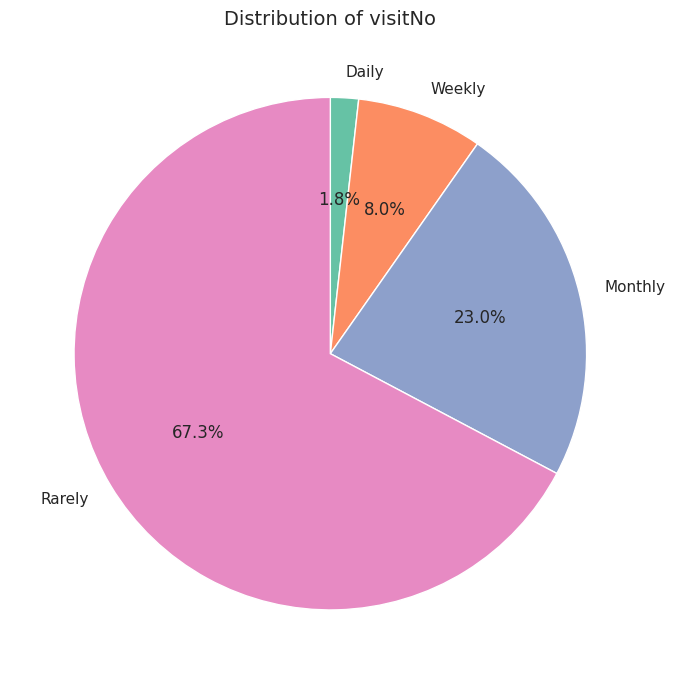

Insight: Phân phối visitNo là nền để tạo return_group. Trong dataset này cần nhìn thêm tỷ lệ Frequent/Infrequent thay vì chỉ xem số lượng từng nhãn. nhóm `Rarely` chiếm nhiều nhất với 76 khách (67.3%).


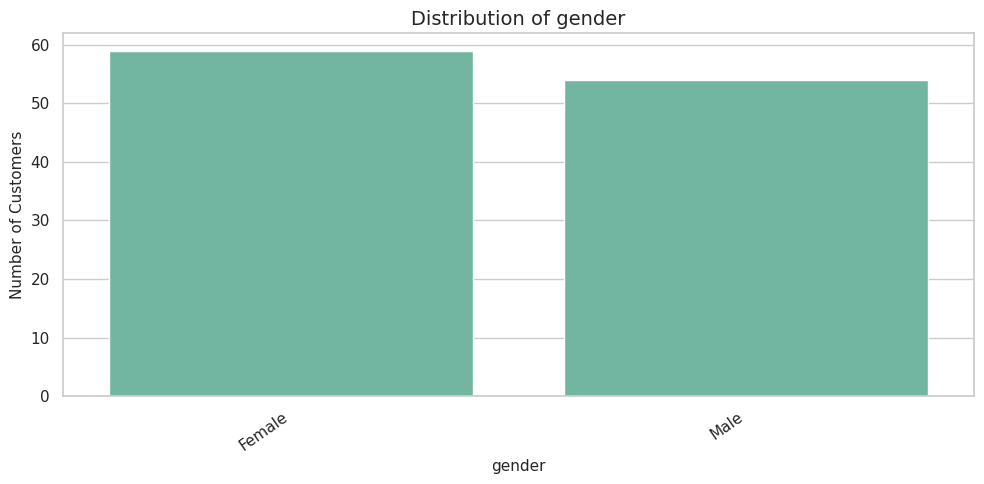

Insight: Gender có phân phối tương đối cân bằng giữa Male/Female, nhưng insight về return behavior cần dựa vào bảng tỷ lệ vì biến này không nên được xem là yếu tố giải thích chính. nhóm `Female` chiếm nhiều nhất với 59 khách (52.2%).


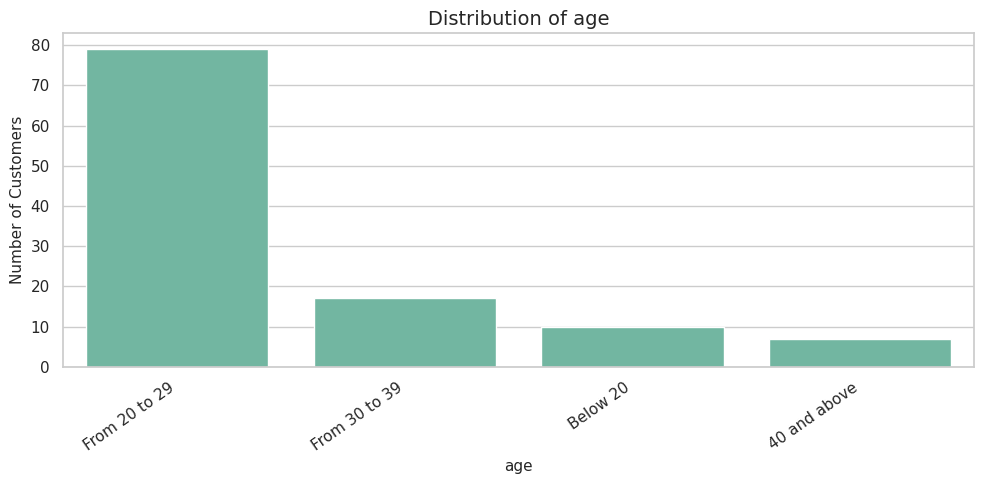

Insight: Age tập trung nhiều ở nhóm From 20 to 29. Các nhóm tuổi lớn hơn có số mẫu ít hơn nên nếu frequent_rate cao cũng cần diễn giải thận trọng. nhóm `From 20 to 29` chiếm nhiều nhất với 79 khách (69.9%).


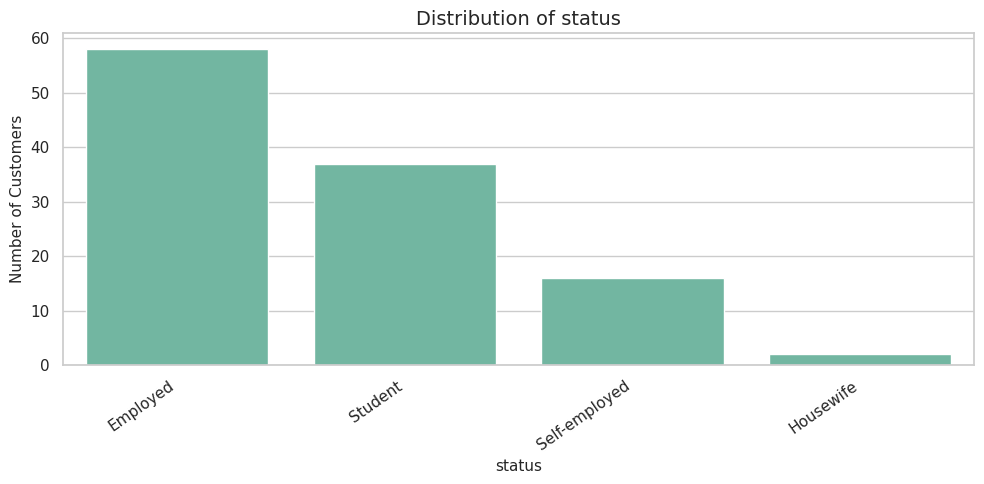

Insight: Employed là nhóm có số lượng lớn nhất, Student đứng sau và Self-employed có mẫu nhỏ hơn. Đây là lý do cần deep dive riêng cho 3 nhóm này. nhóm `Employed` chiếm nhiều nhất với 58 khách (51.3%).


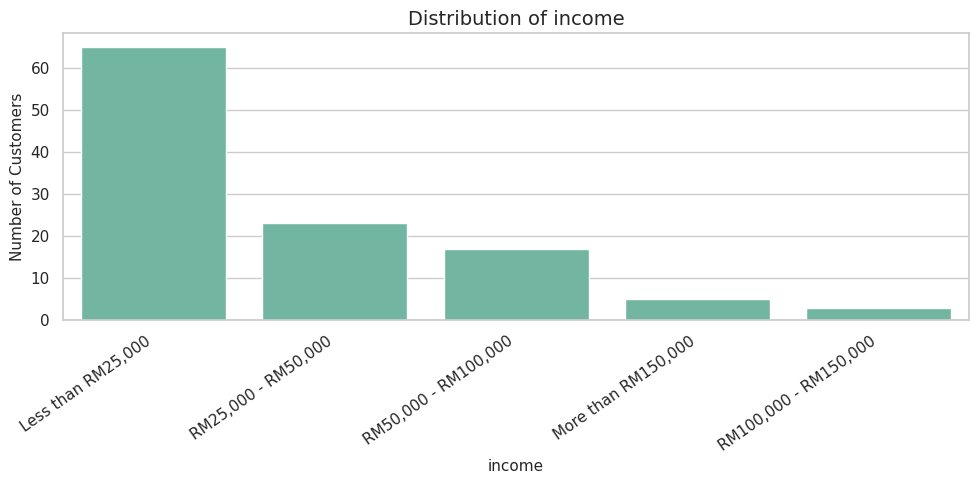

Insight: Nhóm Less than RM25,000 chiếm nhiều trong dataset. Điều này cần được xem cùng frequent_rate vì nhóm thu nhập cao có số lượng mẫu nhỏ. nhóm `Less than RM25,000` chiếm nhiều nhất với 65 khách (57.5%).


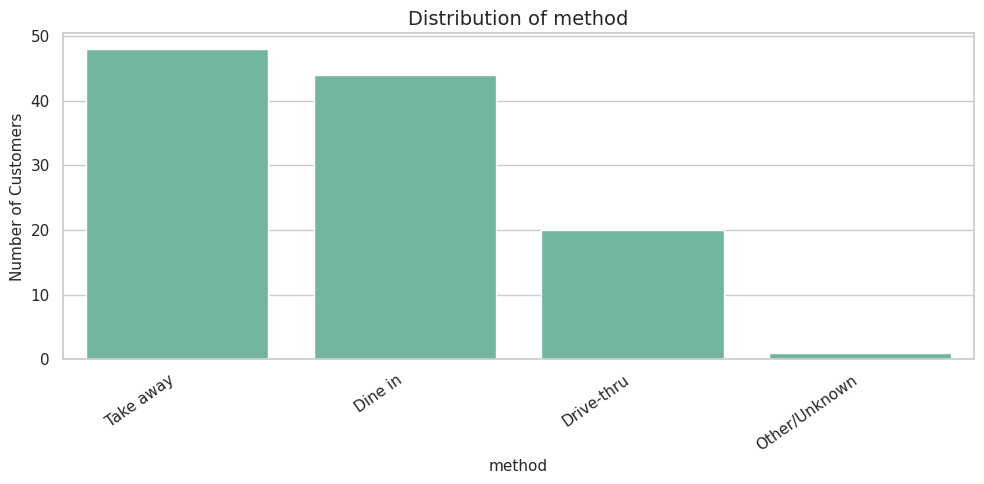

Insight: Take away và Dine in là hai hình thức phổ biến. Method cần được diễn giải thận trọng vì bảng tỷ lệ cho thấy chênh lệch Frequent giữa các hình thức không lớn. nhóm `Take away` chiếm nhiều nhất với 48 khách (42.5%).


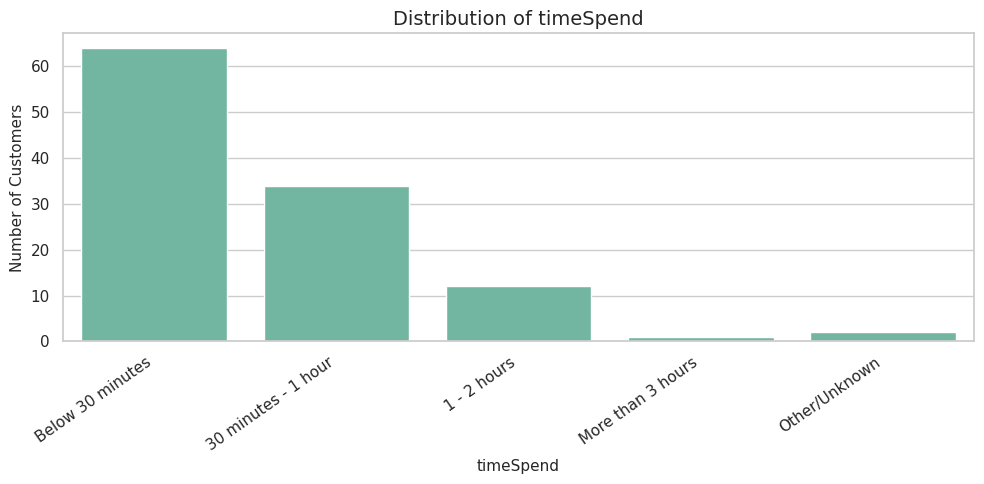

Insight: Below 30 minutes là nhóm phổ biến nhất. Các nhóm ở lại lâu hơn có số mẫu nhỏ hơn, nên insight cần kết hợp với bảng tỷ lệ. nhóm `Below 30 minutes` chiếm nhiều nhất với 64 khách (56.6%).


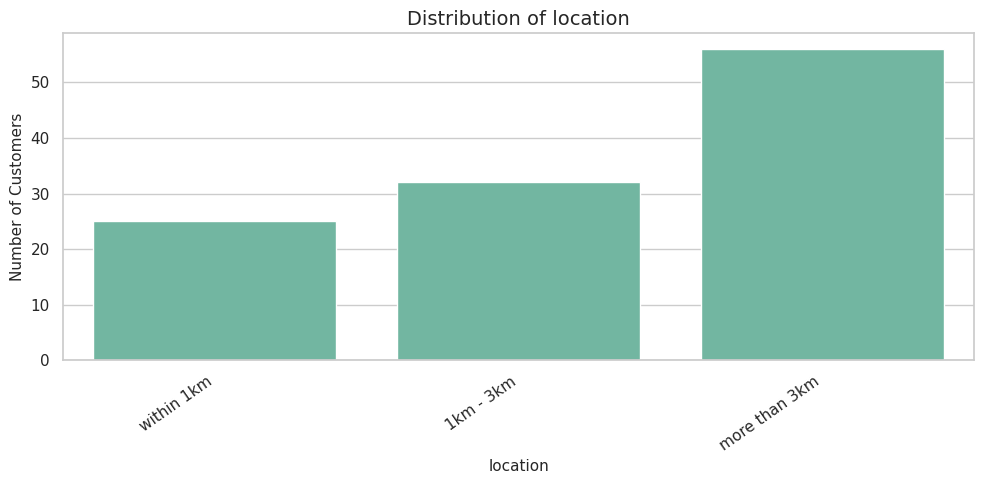

Insight: Location phân phối nhiều ở nhóm more than 3km. Không nên mặc định khách gần cửa hàng sẽ quay lại nhiều hơn nếu bảng tỷ lệ không ủng hộ rõ. nhóm `more than 3km` chiếm nhiều nhất với 56 khách (49.6%).


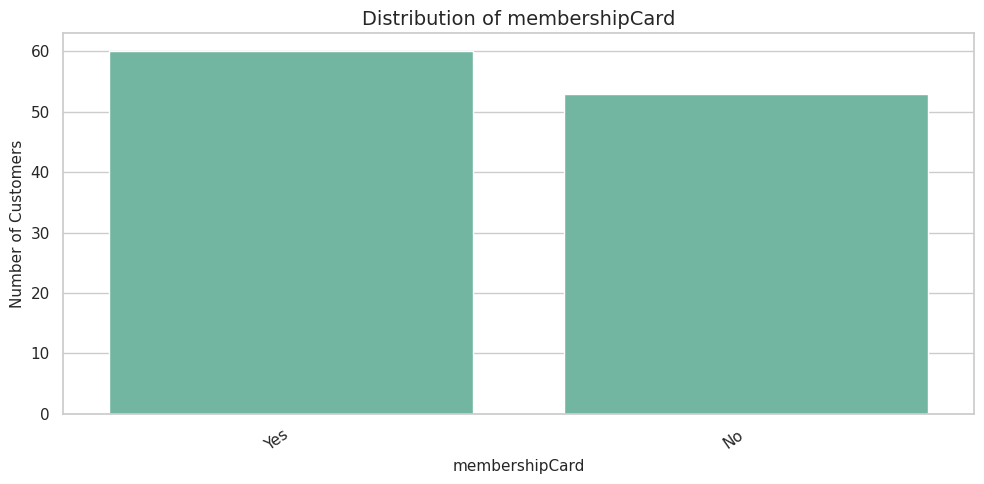

Insight: MembershipCard có hai nhóm Yes/No khá đáng kể. Cần kiểm chứng tỷ lệ Frequent để xem membership có thể phản ánh mức độ gắn bó hay không. nhóm `Yes` chiếm nhiều nhất với 60 khách (53.1%).


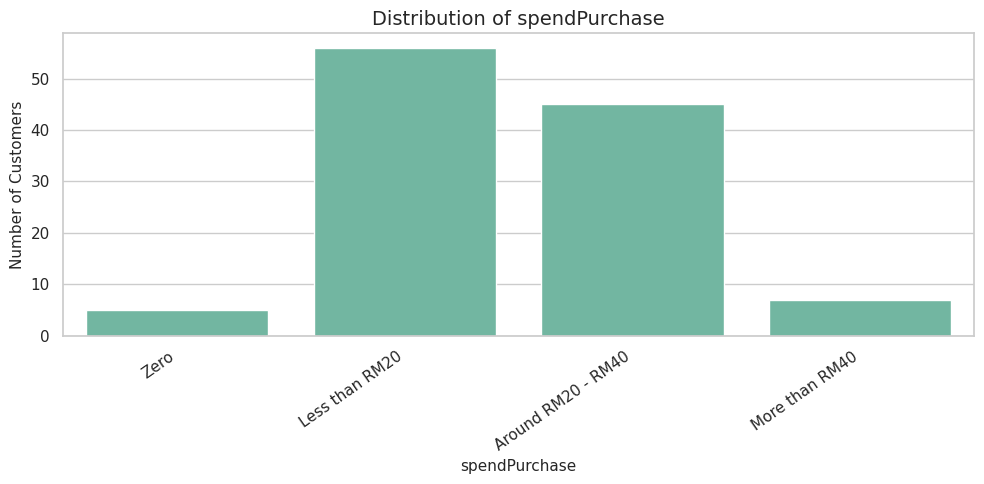

Insight: Less than RM20 và Around RM20 - RM40 là hai nhóm chính. Bảng tỷ lệ sẽ cho biết mức chi tiêu có đi cùng return_group hay không. nhóm `Less than RM20` chiếm nhiều nhất với 56 khách (49.6%).


In [39]:
def top_text(data, col):
    lab = get_label_col(col)
    if lab not in data.columns: return 'không đủ dữ liệu.'
    vc = data[lab].value_counts(dropna=False)
    if vc.empty: return 'không đủ dữ liệu.'
    return f'nhóm `{vc.index[0]}` chiếm nhiều nhất với {vc.iloc[0]} khách ({vc.iloc[0]/vc.sum()*100:.1f}%).'

def plot_count(data, col, title, insight):
    lab = get_label_col(col)
    temp = data.copy()
    if lab not in temp.columns:
        if not has_col(temp, col): return False
        temp[lab] = make_label(temp, col)
    if temp.empty: print(f'Skip `{col}`: no data.'); return False
    plt.figure(figsize=(10,5))
    ax = sns.countplot(data=temp, x=lab, order=label_order(temp, col), color='C0')
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel('Number of Customers')
    plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()
    print('Insight:', insight)
    return True

def plot_pie_distribution(data, col, title, insight):
    lab = get_label_col(col)
    temp = data.copy()
    if lab not in temp.columns:
        if not has_col(temp, col): return False
        temp[lab] = make_label(temp, col)
    if temp.empty: print(f'Skip `{col}`: no data.'); return False
    order = label_order(temp, col)
    counts = temp[lab].value_counts(dropna=False)
    counts = counts.reindex([x for x in order if x in counts.index])
    plt.figure(figsize=(7,7))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, counterclock=False)
    plt.title(title); plt.tight_layout(); plt.show()
    print('Insight:', insight)
    return True

main_insights = {
'visitNo':'Phân phối visitNo là nền để tạo return_group. Trong dataset này cần nhìn thêm tỷ lệ Frequent/Infrequent thay vì chỉ xem số lượng từng nhãn.',
'gender':'Gender có phân phối tương đối cân bằng giữa Male/Female, nhưng insight về return behavior cần dựa vào bảng tỷ lệ vì biến này không nên được xem là yếu tố giải thích chính.',
'age':'Age tập trung nhiều ở nhóm From 20 to 29. Các nhóm tuổi lớn hơn có số mẫu ít hơn nên nếu frequent_rate cao cũng cần diễn giải thận trọng.',
'status':'Employed là nhóm có số lượng lớn nhất, Student đứng sau và Self-employed có mẫu nhỏ hơn. Đây là lý do cần deep dive riêng cho 3 nhóm này.',
'income':'Nhóm Less than RM25,000 chiếm nhiều trong dataset. Điều này cần được xem cùng frequent_rate vì nhóm thu nhập cao có số lượng mẫu nhỏ.',
'method':'Take away và Dine in là hai hình thức phổ biến. Method cần được diễn giải thận trọng vì bảng tỷ lệ cho thấy chênh lệch Frequent giữa các hình thức không lớn.',
'timeSpend':'Below 30 minutes là nhóm phổ biến nhất. Các nhóm ở lại lâu hơn có số mẫu nhỏ hơn, nên insight cần kết hợp với bảng tỷ lệ.',
'location':'Location phân phối nhiều ở nhóm more than 3km. Không nên mặc định khách gần cửa hàng sẽ quay lại nhiều hơn nếu bảng tỷ lệ không ủng hộ rõ.',
'membershipCard':'MembershipCard có hai nhóm Yes/No khá đáng kể. Cần kiểm chứng tỷ lệ Frequent để xem membership có thể phản ánh mức độ gắn bó hay không.',
'spendPurchase':'Less than RM20 và Around RM20 - RM40 là hai nhóm chính. Bảng tỷ lệ sẽ cho biết mức chi tiêu có đi cùng return_group hay không.'}
for col in ['visitNo','gender','age','status','income','method','timeSpend','location','membershipCard','spendPurchase']:
    if col == 'visitNo':
        plot_pie_distribution(df, col, f'Distribution of {col}', main_insights[col] + ' ' + top_text(df, col))
    else:
        plot_count(df, col, f'Distribution of {col}', main_insights[col] + ' ' + top_text(df, col))

Additional univariate columns, promotion columns excluded:


,candidate_univariate_cols
0,itemPurchaseCoffee
1,itempurchaseCold
2,itemPurchasePastries
3,itemPurchaseJuices
4,itemPurchaseSandwiches
5,itemPurchaseOthers
6,productRate
7,priceRate
8,ambianceRate
9,wifiRate


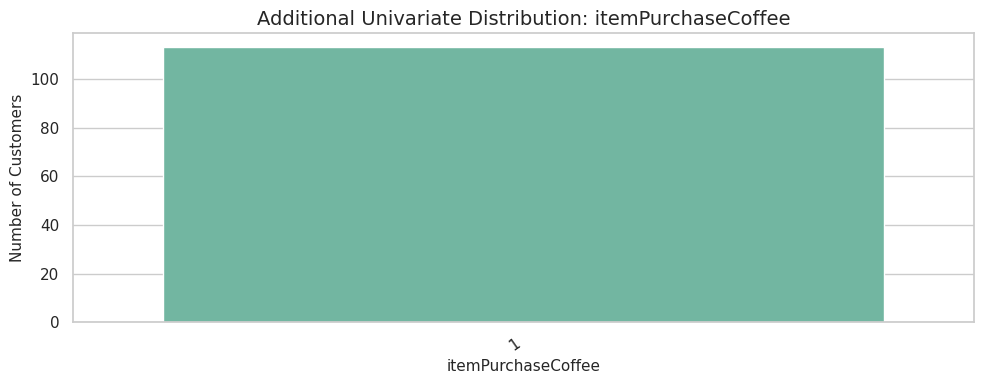

Insight: Với biến `itemPurchaseCoffee`, nhóm `1` chiếm nhiều nhất với 113 khách (100.0%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.


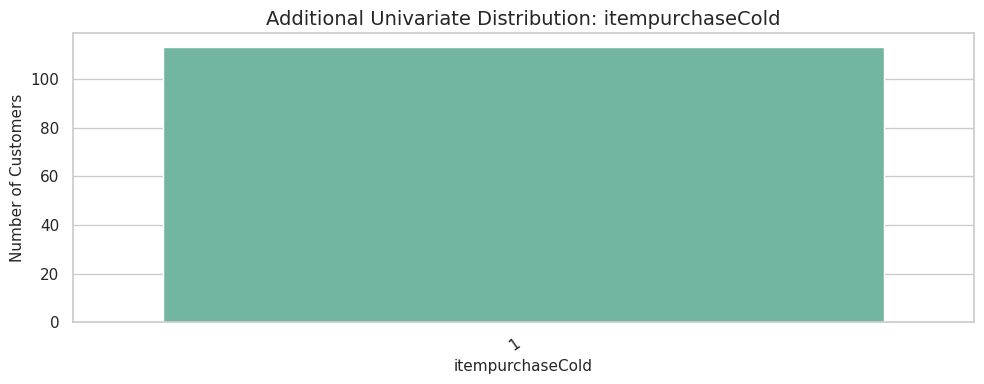

Insight: Với biến `itempurchaseCold`, nhóm `1` chiếm nhiều nhất với 113 khách (100.0%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.


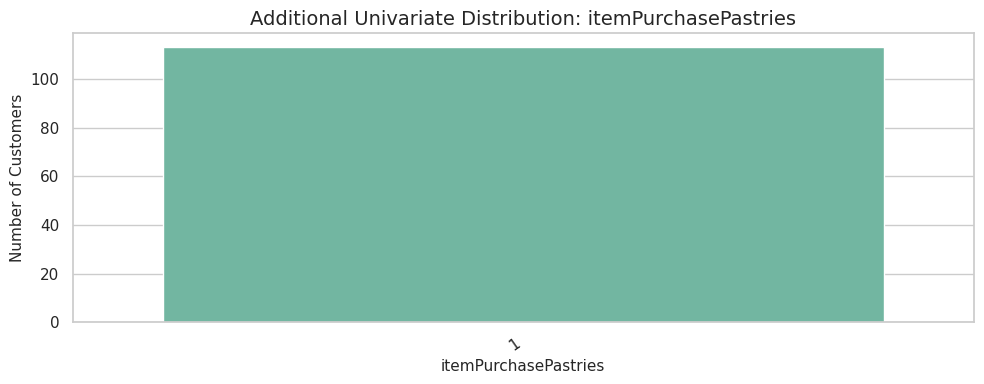

Insight: Với biến `itemPurchasePastries`, nhóm `1` chiếm nhiều nhất với 113 khách (100.0%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.


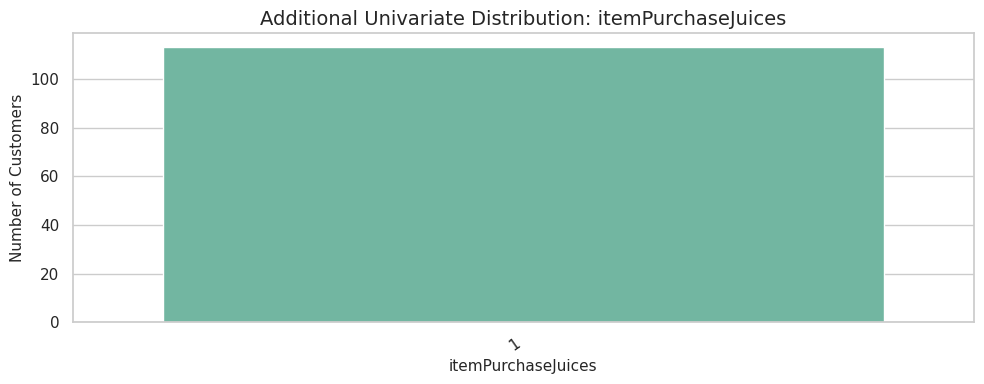

Insight: Với biến `itemPurchaseJuices`, nhóm `1` chiếm nhiều nhất với 113 khách (100.0%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.


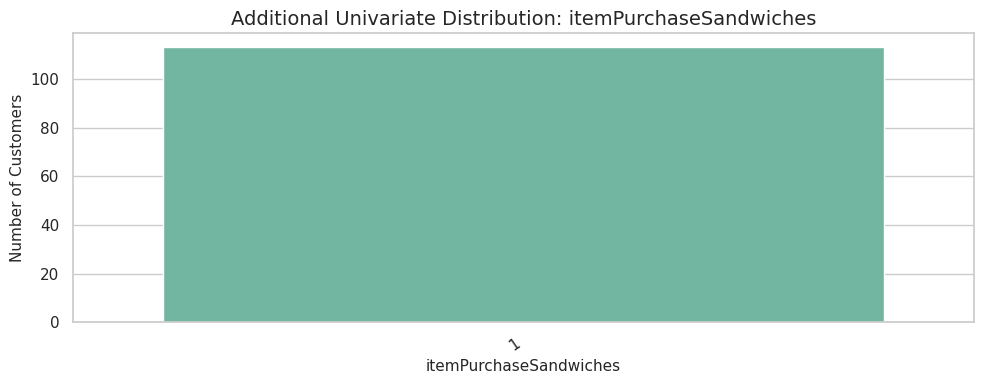

Insight: Với biến `itemPurchaseSandwiches`, nhóm `1` chiếm nhiều nhất với 113 khách (100.0%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.


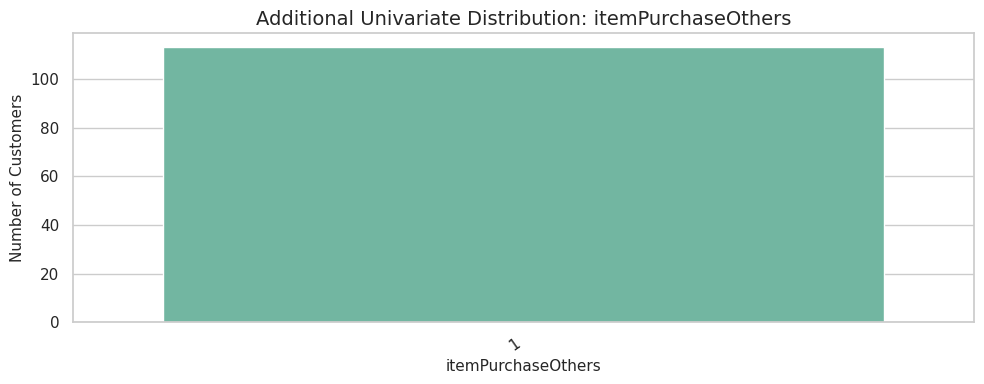

Insight: Với biến `itemPurchaseOthers`, nhóm `1` chiếm nhiều nhất với 113 khách (100.0%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.
1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).


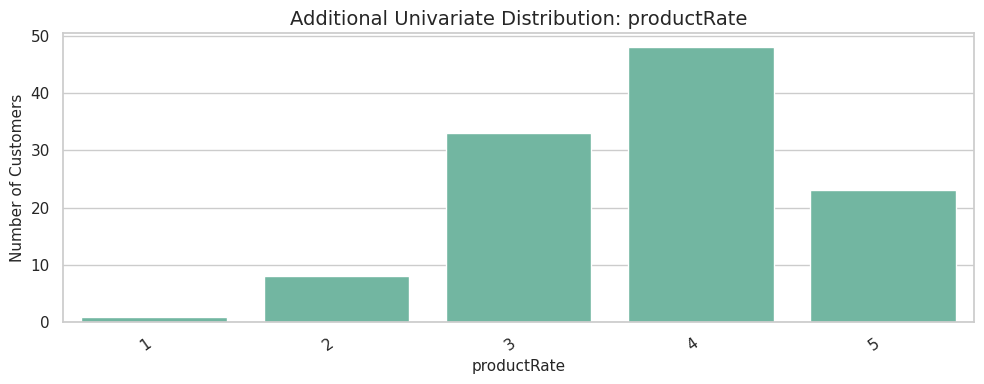

Insight: Với biến `productRate`, nhóm `4` chiếm nhiều nhất với 48 khách (42.5%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.
1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).


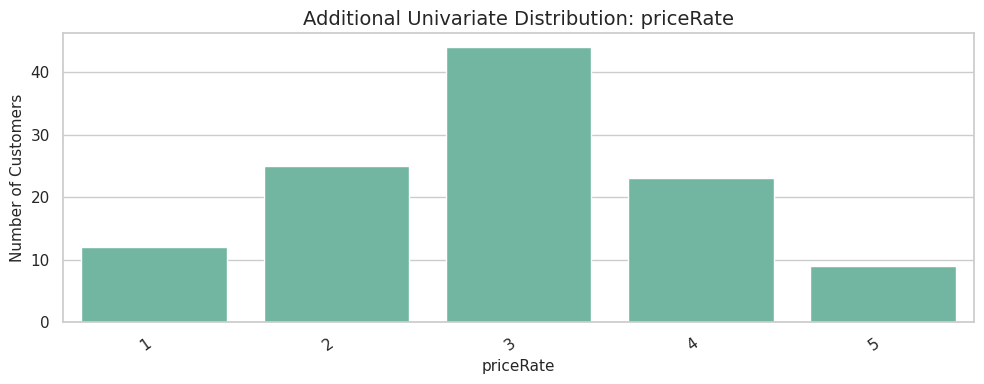

Insight: Với biến `priceRate`, nhóm `3` chiếm nhiều nhất với 44 khách (38.9%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.
1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).


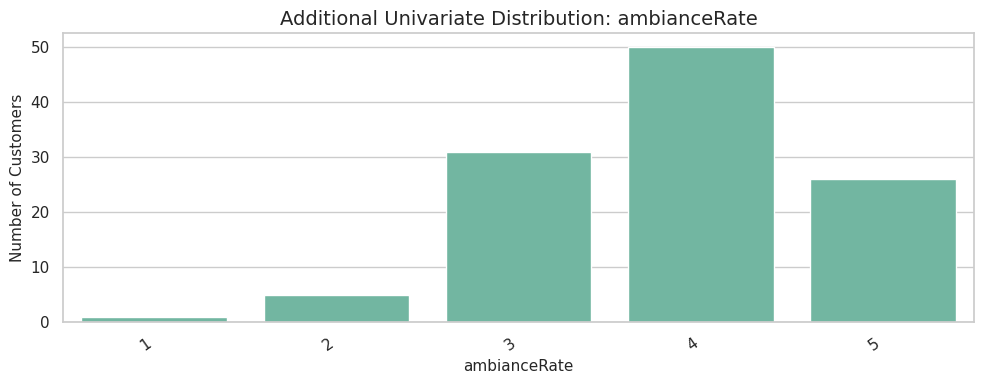

Insight: Với biến `ambianceRate`, nhóm `4` chiếm nhiều nhất với 50 khách (44.2%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.
1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).


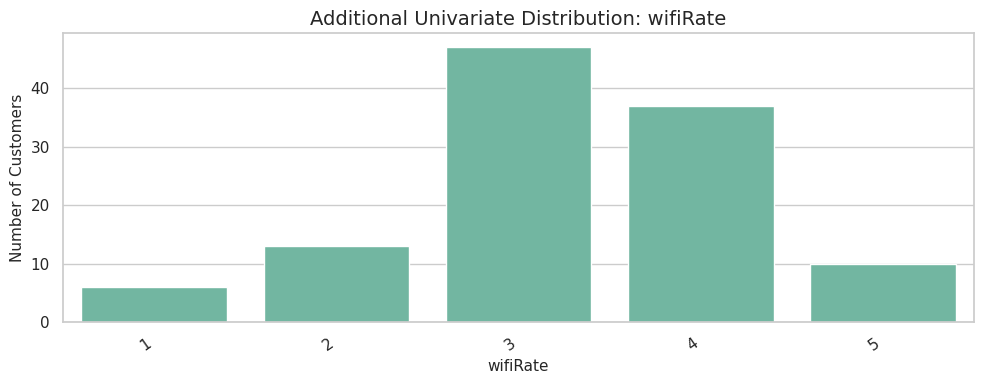

Insight: Với biến `wifiRate`, nhóm `3` chiếm nhiều nhất với 47 khách (41.6%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.
1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).


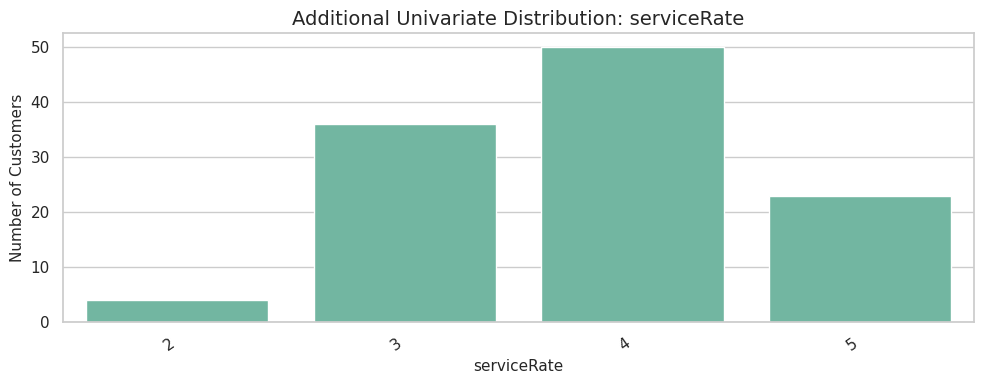

Insight: Với biến `serviceRate`, nhóm `4` chiếm nhiều nhất với 50 khách (44.2%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.
1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).


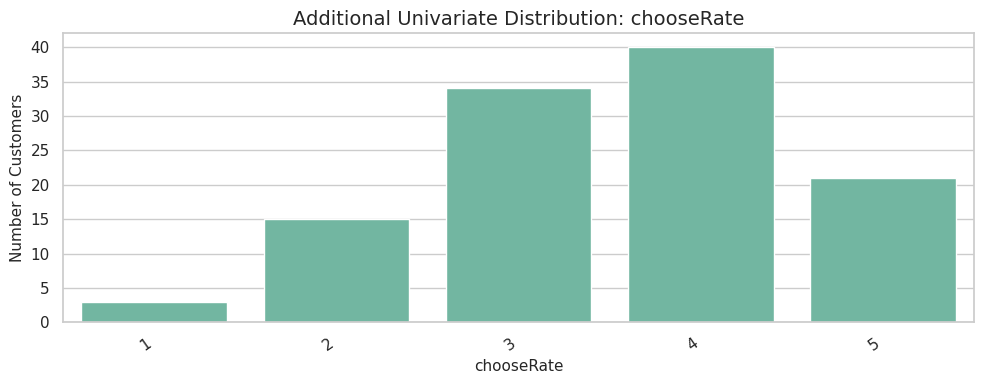

Insight: Với biến `chooseRate`, nhóm `4` chiếm nhiều nhất với 40 khách (35.4%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.
1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).


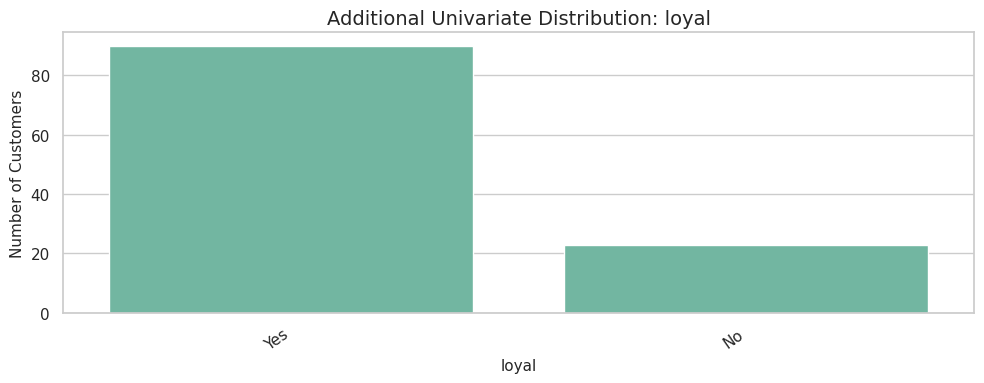

Insight: Với biến `loyal`, nhóm `Yes` chiếm nhiều nhất với 90 khách (79.6%). Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.


In [40]:
excluded_keywords = ['promo','promotion','sales','discount','offer','channel','hear','social','deal']
main_cols = {'visitNo','gender','age','status','income','method','timeSpend','location','membershipCard','spendPurchase'}
label_cols = set(label_columns.values())
def is_excluded(col): return any(k in col.lower() for k in excluded_keywords)
candidate_univariate_cols = []
for col in df.columns:
    if col in main_cols or col in label_cols or col in {'Id','id','index','return_group'} or col.endswith('_score') or is_excluded(col): continue
    if 1 <= df[col].nunique(dropna=True) <= 15: candidate_univariate_cols.append(col)
print('Additional univariate columns, promotion columns excluded:')
display(pd.DataFrame({'candidate_univariate_cols': candidate_univariate_cols}))

cnt = 6
for col in candidate_univariate_cols:
    cnt -=1
    if cnt < 0: print('1: Rất tệ (Thất vọng) | 2: Tệ (Kém) | 3: Trung bình (Tạm ổn) | 4: Tốt (Hài lòng) | 5: Xuất sắc (Hoàn hảo).')
    temp = df.copy(); lab = get_label_col(col)
    if lab not in temp.columns: temp[lab] = make_label(temp, col) if col in label_maps else clean_series(temp[col]).fillna('Missing')
    
    # Sắp xếp theo thứ tự 0, 1, 2, 3, 4, 5 (không đảo lộn xộ)
    vc = temp[lab].value_counts()
    try:
        # Thử convert sang int để sắp xếp theo thứ tự số
        numeric_vals = sorted([x for x in vc.index if str(x).replace('.','').isdigit()], key=lambda x: int(float(x)))
        other_vals = [x for x in vc.index if not str(x).replace('.','').isdigit()]
        chart_order = numeric_vals + other_vals
        if not chart_order: chart_order = vc.index
    except:
        chart_order = vc.index
    
    plt.figure(figsize=(10,4)); ax=sns.countplot(data=temp, x=lab, order=chart_order, color='C0')
    ax.set_title(f'Additional Univariate Distribution: {col}'); ax.set_xlabel(col); ax.set_ylabel('Number of Customers')
    plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()
    print(f'Insight: Với biến `{col}`, {top_text(temp, col)} Đây là thông tin mô tả bổ sung; chưa nên diễn giải là yếu tố chính nếu chưa đối chiếu với return_group.')

## 7. Bivariate Analysis

Phần này so sánh từng biến với `return_group`. Các insight dựa trên bảng validation, không diễn giải theo hướng nhân quả.

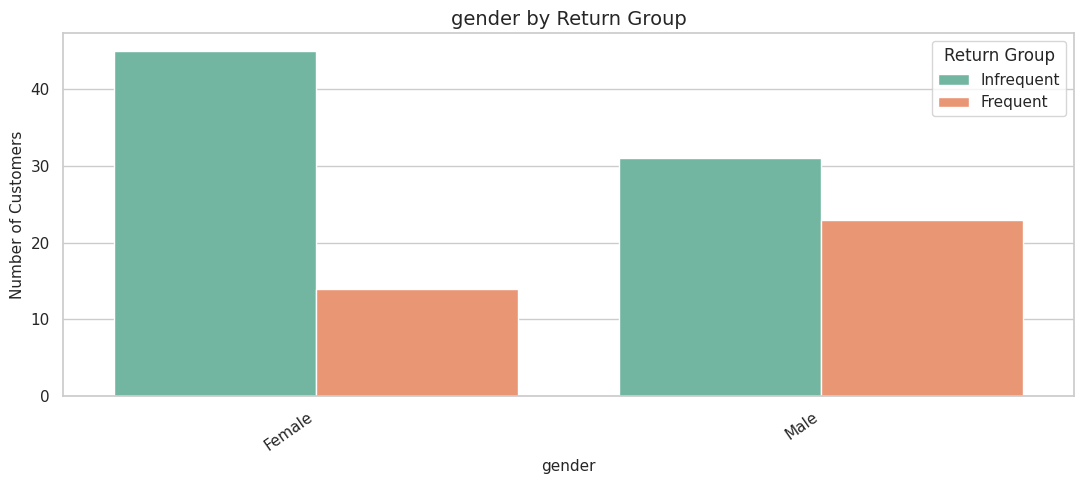

Insight: Gender có sự chênh lệch về frequent_rate trong dataset này, nhưng vì mẫu nhỏ và đây là biến nhân khẩu học, chưa nên xem gender là yếu tố giải thích chính.


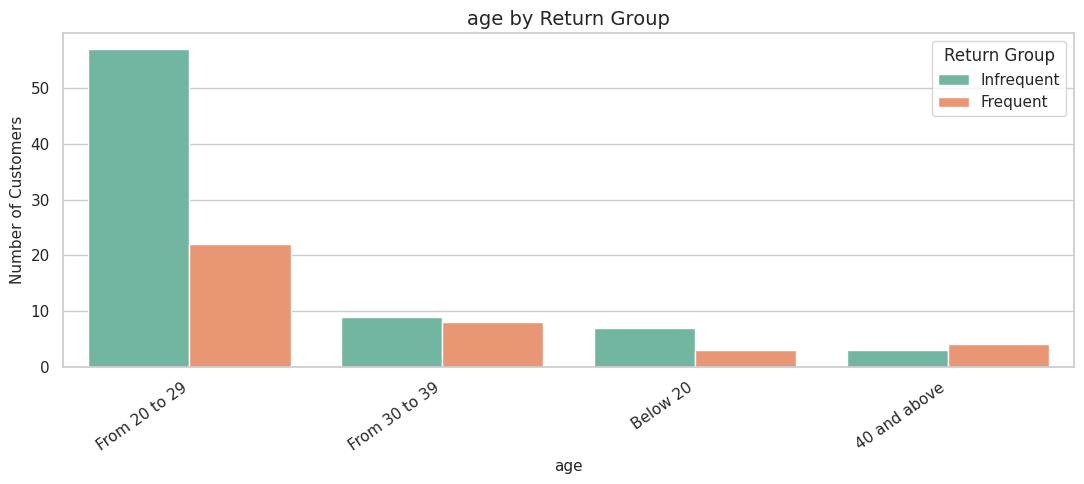

Insight: Age có chênh lệch giữa các nhóm, nhưng một số nhóm tuổi có ít mẫu nên chỉ nên xem age là biến hỗ trợ phân tích.


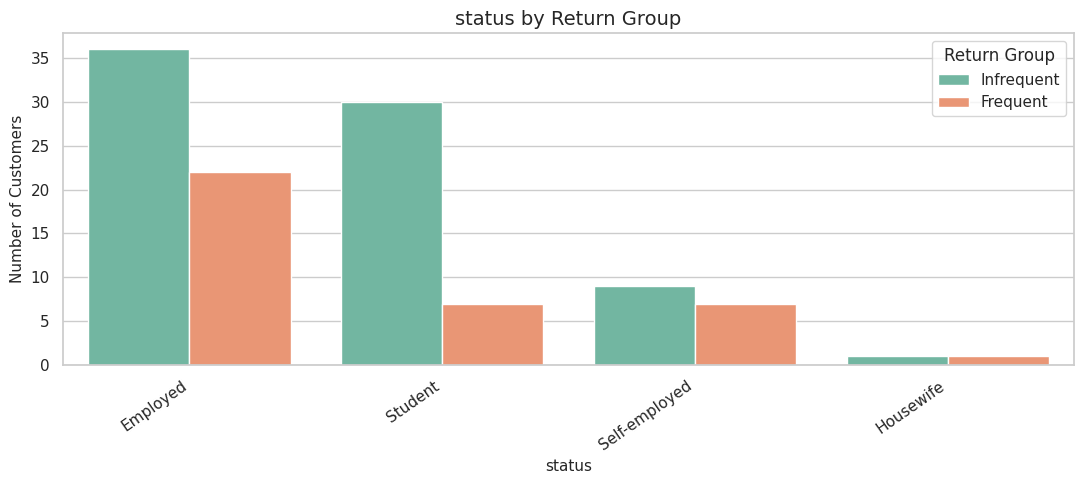

Insight: Status cho thấy Student có frequent_rate thấp hơn Employed và Self-employed trong dataset này; Housewife có mẫu rất nhỏ nên không diễn giải mạnh.


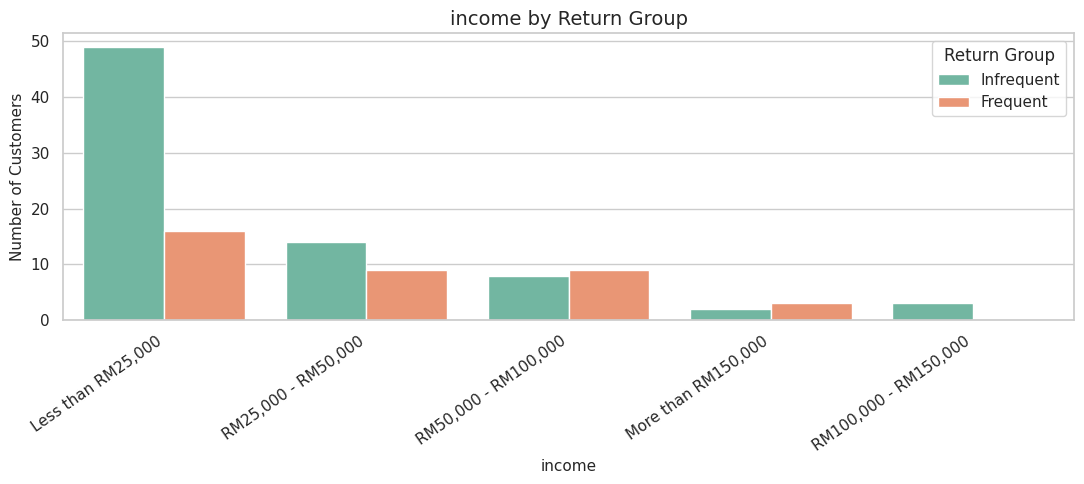

Insight: Nhóm thu nhập thấp chiếm nhiều và có frequent_rate thấp hơn một số nhóm trung bình/cao. Tuy nhiên nhóm thu nhập rất cao có ít mẫu nên không kết luận quá mạnh.


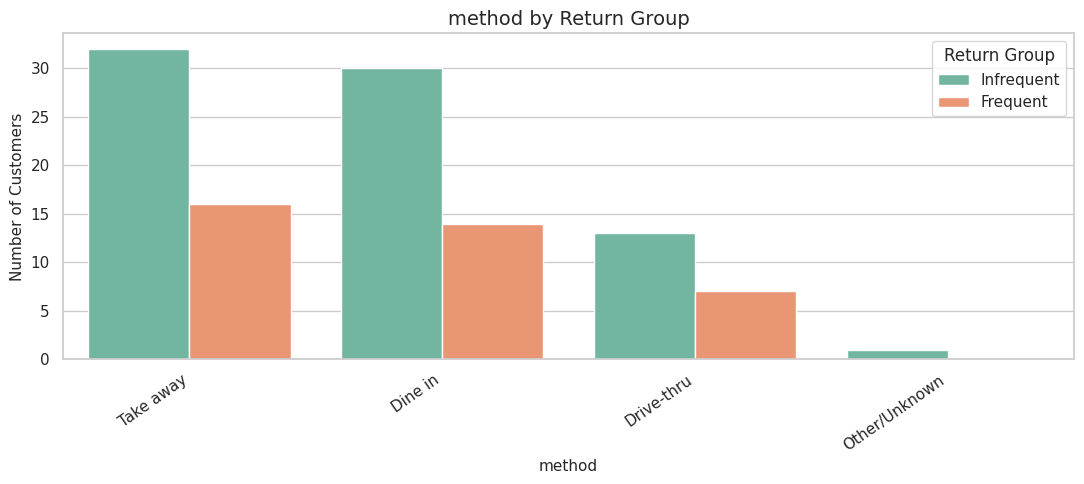

Insight: Method không tạo khác biệt lớn giữa Frequent và Infrequent trong dataset này; Drive-thru, Take away và Dine in có frequent_rate khá gần nhau.


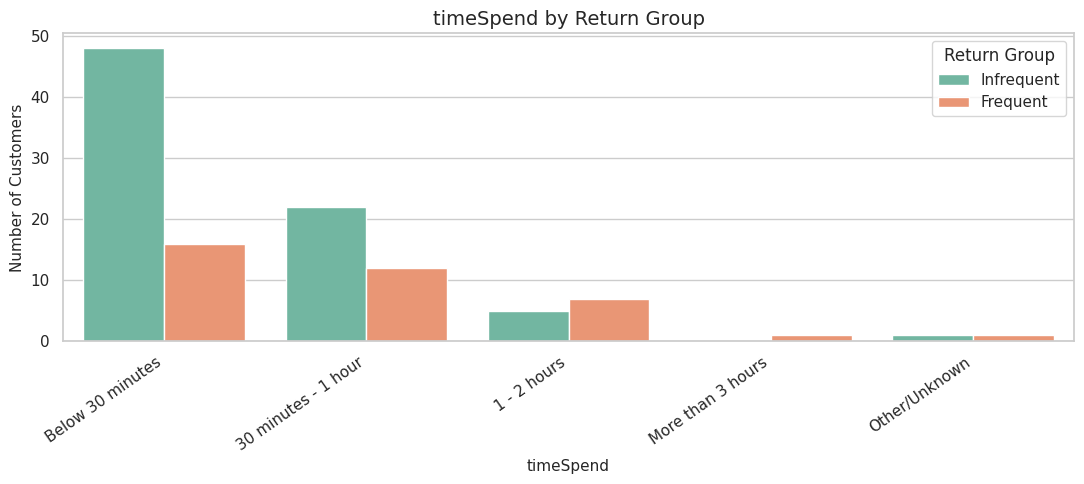

Insight: Khách ở lại 1-2 giờ có frequent_rate cao hơn nhóm dưới 30 phút. Nhóm trên 3 giờ có mẫu rất nhỏ nên không diễn giải mạnh.


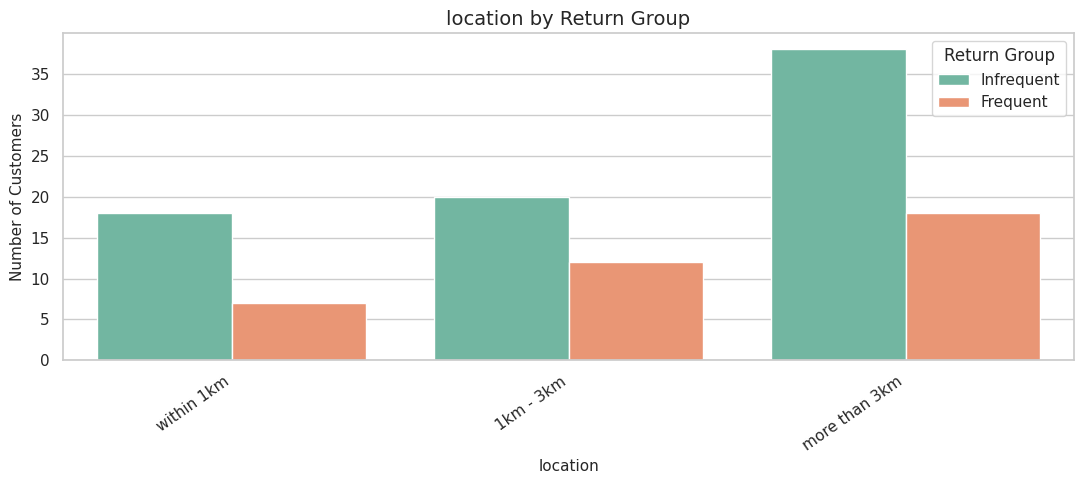

Insight: Location chưa cho thấy xu hướng thật sự rõ rằng khách ở gần cửa hàng sẽ quay lại thường xuyên hơn; nhóm 1km-3km cao hơn within 1km trong dataset này.


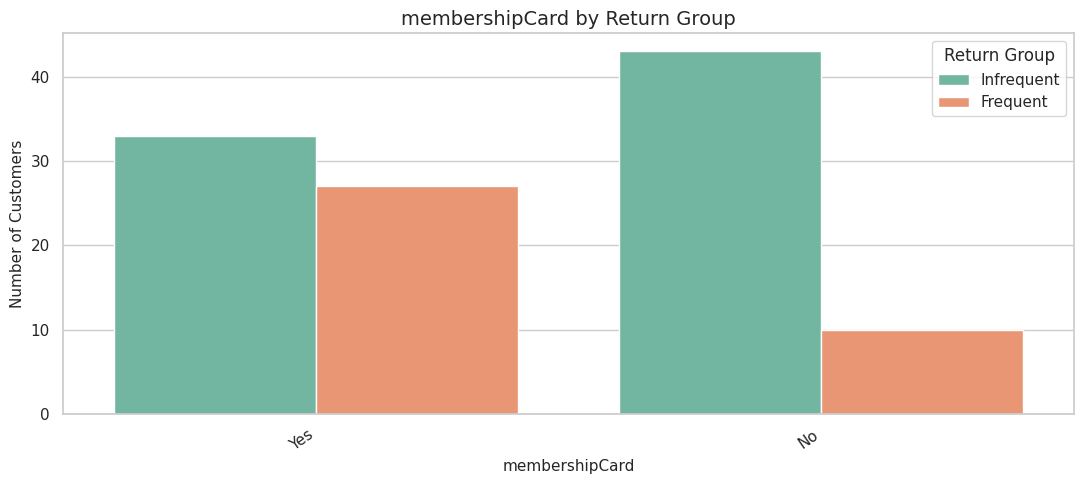

Insight: Khách có membership card có frequent_rate cao hơn nhóm không có membership card. Điều này có thể phản ánh mức độ gắn bó, nhưng không chứng minh nguyên nhân trực tiếp.


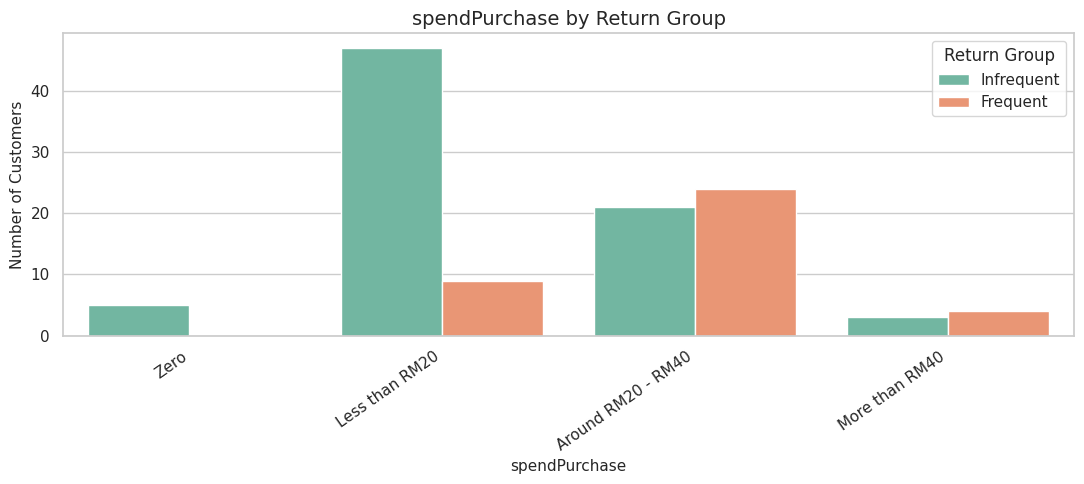

Insight: Mức chi tiêu có xu hướng đi cùng return_group; nhóm RM20-40 và hơn RM40 có frequent_rate cao hơn nhóm chi tiêu thấp.


In [41]:
def plot_by_return_group(data, col, insight):
    lab = get_label_col(col); temp = data.copy()
    if lab not in temp.columns:
        if not has_col(temp, col): return False
        temp[lab] = make_label(temp, col)
    if 'return_group' not in temp.columns: print('Skip: return_group missing.'); return False
    temp = temp[temp['return_group'].isin(['Frequent','Infrequent'])]
    if temp.empty: print(f'Skip `{col}`: no data.'); return False
    plt.figure(figsize=(11,5)); ax=sns.countplot(data=temp, x=lab, hue='return_group', order=label_order(temp,col), palette='Set2')
    ax.set_title(f'{col} by Return Group'); ax.set_xlabel(col); ax.set_ylabel('Number of Customers'); ax.legend(title='Return Group')
    plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()
    print('Insight:', insight)
    return True
biv_insights = {
'gender':'Gender có sự chênh lệch về frequent_rate trong dataset này, nhưng vì mẫu nhỏ và đây là biến nhân khẩu học, chưa nên xem gender là yếu tố giải thích chính.',
'age':'Age có chênh lệch giữa các nhóm, nhưng một số nhóm tuổi có ít mẫu nên chỉ nên xem age là biến hỗ trợ phân tích.',
'status':'Status cho thấy Student có frequent_rate thấp hơn Employed và Self-employed trong dataset này; Housewife có mẫu rất nhỏ nên không diễn giải mạnh.',
'income':'Nhóm thu nhập thấp chiếm nhiều và có frequent_rate thấp hơn một số nhóm trung bình/cao. Tuy nhiên nhóm thu nhập rất cao có ít mẫu nên không kết luận quá mạnh.',
'method':'Method không tạo khác biệt lớn giữa Frequent và Infrequent trong dataset này; Drive-thru, Take away và Dine in có frequent_rate khá gần nhau.',
'timeSpend':'Khách ở lại 1-2 giờ có frequent_rate cao hơn nhóm dưới 30 phút. Nhóm trên 3 giờ có mẫu rất nhỏ nên không diễn giải mạnh.',
'location':'Location chưa cho thấy xu hướng thật sự rõ rằng khách ở gần cửa hàng sẽ quay lại thường xuyên hơn; nhóm 1km-3km cao hơn within 1km trong dataset này.',
'membershipCard':'Khách có membership card có frequent_rate cao hơn nhóm không có membership card. Điều này có thể phản ánh mức độ gắn bó, nhưng không chứng minh nguyên nhân trực tiếp.',
'spendPurchase':'Mức chi tiêu có xu hướng đi cùng return_group; nhóm RM20-40 và hơn RM40 có frequent_rate cao hơn nhóm chi tiêu thấp.'}
for col in ['gender','age','status','income','method','timeSpend','location','membershipCard','spendPurchase']:
    plot_by_return_group(df, col, biv_insights.get(col, 'No insight available.'))

In [42]:
print('Automatic validated insights:')
for col in ['status','income','location','membershipCard','spendPurchase','timeSpend','gender','method']:
    table = rate_tables.get(col, pd.DataFrame())
    if table.empty: continue
    top = table.iloc[0]
    note = ' Lưu ý: nhóm này có mẫu nhỏ nên chỉ xem là tín hiệu tham khảo.' if top['total_customers'] < 10 else ''
    print(f"- Trong biến {col}, nhóm có frequent_rate_% cao nhất là `{top['group']}` với {top['frequent_rate_%']}% ({int(top['frequent_customers'])}/{int(top['total_customers'])} khách).{note}")

Automatic validated insights:
- Trong biến status, nhóm có frequent_rate_% cao nhất là `Housewife` với 50.0% (1/2 khách). Lưu ý: nhóm này có mẫu nhỏ nên chỉ xem là tín hiệu tham khảo.
- Trong biến income, nhóm có frequent_rate_% cao nhất là `More than RM150,000` với 60.0% (3/5 khách). Lưu ý: nhóm này có mẫu nhỏ nên chỉ xem là tín hiệu tham khảo.
- Trong biến location, nhóm có frequent_rate_% cao nhất là `1km - 3km` với 37.5% (12/32 khách).
- Trong biến membershipCard, nhóm có frequent_rate_% cao nhất là `Yes` với 45.0% (27/60 khách).
- Trong biến spendPurchase, nhóm có frequent_rate_% cao nhất là `More than RM40` với 57.14% (4/7 khách). Lưu ý: nhóm này có mẫu nhỏ nên chỉ xem là tín hiệu tham khảo.
- Trong biến timeSpend, nhóm có frequent_rate_% cao nhất là `More than 3 hours` với 100.0% (1/1 khách). Lưu ý: nhóm này có mẫu nhỏ nên chỉ xem là tín hiệu tham khảo.
- Trong biến gender, nhóm có frequent_rate_% cao nhất là `Male` với 42.59% (23/54 khách).
- Trong biến method, nhóm có frequent

## 8. Multivariate Analysis

Phần này xem nhiều biến cùng lúc. Các insight được viết như mối liên hệ trong dataset, không phải quan hệ nhân quả.

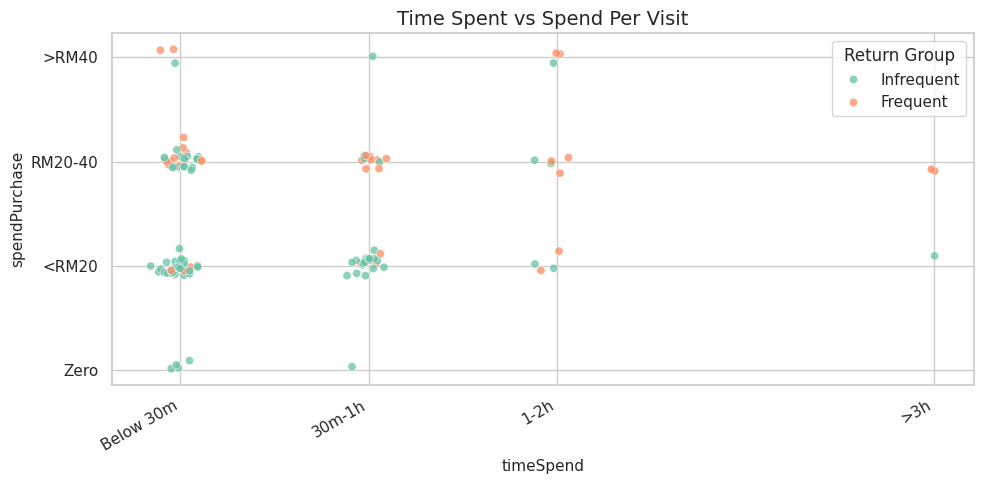

Insight: Biểu đồ cho thấy khách hàng ở lại Starbucks lâu hơn thường xuất hiện nhiều hơn ở các mức chi tiêu trung bình và cao. Cụ thể, nhóm ở lại từ 1–2 giờ có tỷ lệ Frequent cao hơn nhóm dưới 30 phút, trong khi nhóm dưới 30 phút tập trung nhiều hơn ở mức chi tiêu thấp.

Điều này gợi ý rằng thời gian ở lại quán có thể liên quan đến mức độ gắn bó và giá trị chi tiêu của khách hàng. Tuy nhiên, một số nhóm thời gian dài như 2–3 giờ hoặc trên 3 giờ có số lượng mẫu rất nhỏ, nên không nên diễn giải quá mạnh.


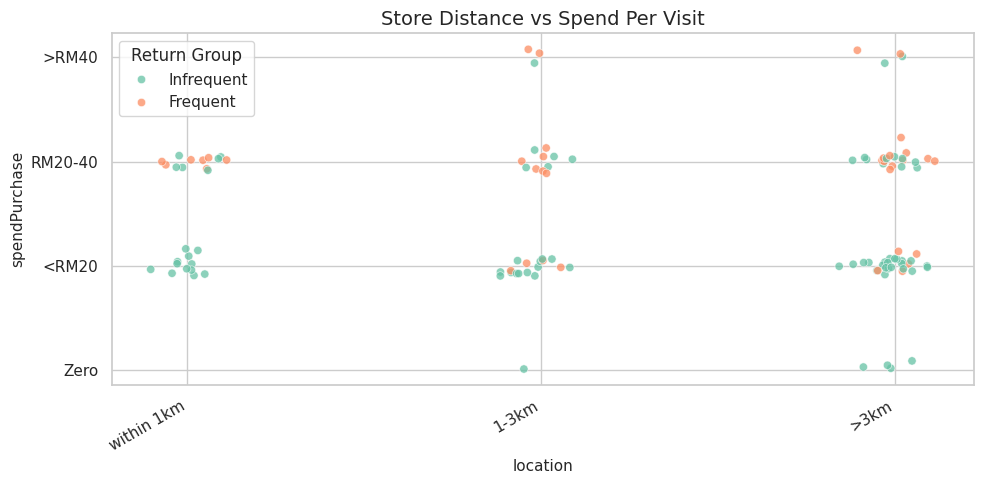

Insight: Biểu đồ cho thấy mức chi tiêu phân bố khác nhau giữa các nhóm khoảng cách đến cửa hàng. Tuy nhiên, trong dataset này chưa có xu hướng thật sự rõ ràng rằng khách ở gần Starbucks hơn sẽ quay lại thường xuyên hơn hoặc chi tiêu cao hơn.

Nhóm khách trong khoảng 1–3km có tỷ lệ Frequent cao nhất, trong khi nhóm within 1km không nổi bật như kỳ vọng. Vì vậy, location nên được xem là biến hỗ trợ mô tả hành vi khách hàng, chưa đủ mạnh để kết luận rằng khoảng cách gần hơn làm tăng khả năng quay lại.


True

In [43]:
def scatter_with_jitter(data, x_col, y_col, title, x_ticks=None, y_ticks=None, insight=''):
    if not has_col(data,x_col) or not has_col(data,y_col): return False
    temp=data.copy(); temp['x_score']=make_score(temp,x_col); temp['y_score']=make_score(temp,y_col); temp=temp.dropna(subset=['x_score','y_score'])
    if temp.empty: print(f'Skip `{x_col}` vs `{y_col}`: no valid scores.'); return False
    np.random.seed(42); temp['x_jitter']=temp['x_score']+np.random.normal(0,.06,len(temp)); temp['y_jitter']=temp['y_score']+np.random.normal(0,.06,len(temp))
    plt.figure(figsize=(10,5)); ax=sns.scatterplot(data=temp,x='x_jitter',y='y_jitter',hue='return_group',alpha=.75,palette='Set2')
    ax.set_title(title); ax.set_xlabel(x_col); ax.set_ylabel(y_col); ax.legend(title='Return Group')
    if x_ticks: ax.set_xticks(list(x_ticks.keys())); ax.set_xticklabels(list(x_ticks.values()), rotation=30, ha='right')
    if y_ticks: ax.set_yticks(list(y_ticks.keys())); ax.set_yticklabels(list(y_ticks.values()))
    plt.tight_layout(); plt.show(); print('Insight:', insight); return True
scatter_with_jitter(
    df,
    'timeSpend',
    'spendPurchase',
    'Time Spent vs Spend Per Visit',
    {0:'Below 30m',1:'30m-1h',2:'1-2h',4:'>3h'},
    {0:'Zero',1:'<RM20',2:'RM20-40',3:'>RM40'},
    """Biểu đồ cho thấy khách hàng ở lại Starbucks lâu hơn thường xuất hiện nhiều hơn ở các mức chi tiêu trung bình và cao. Cụ thể, nhóm ở lại từ 1–2 giờ có tỷ lệ Frequent cao hơn nhóm dưới 30 phút, trong khi nhóm dưới 30 phút tập trung nhiều hơn ở mức chi tiêu thấp.

Điều này gợi ý rằng thời gian ở lại quán có thể liên quan đến mức độ gắn bó và giá trị chi tiêu của khách hàng. Tuy nhiên, một số nhóm thời gian dài như 2–3 giờ hoặc trên 3 giờ có số lượng mẫu rất nhỏ, nên không nên diễn giải quá mạnh."""
)
scatter_with_jitter(
    df,
    'location',
    'spendPurchase',
    'Store Distance vs Spend Per Visit',
    {0:'within 1km',1:'1-3km',2:'>3km'},
    {0:'Zero',1:'<RM20',2:'RM20-40',3:'>RM40'},
    """Biểu đồ cho thấy mức chi tiêu phân bố khác nhau giữa các nhóm khoảng cách đến cửa hàng. Tuy nhiên, trong dataset này chưa có xu hướng thật sự rõ ràng rằng khách ở gần Starbucks hơn sẽ quay lại thường xuyên hơn hoặc chi tiêu cao hơn.

Nhóm khách trong khoảng 1–3km có tỷ lệ Frequent cao nhất, trong khi nhóm within 1km không nổi bật như kỳ vọng. Vì vậy, location nên được xem là biến hỗ trợ mô tả hành vi khách hàng, chưa đủ mạnh để kết luận rằng khoảng cách gần hơn làm tăng khả năng quay lại."""
)

,visit_label,avg_spend_score,customers
0,Daily,2.000000,2
1,Weekly,2.111111,9
2,Monthly,1.769231,26
3,Rarely,1.289474,76


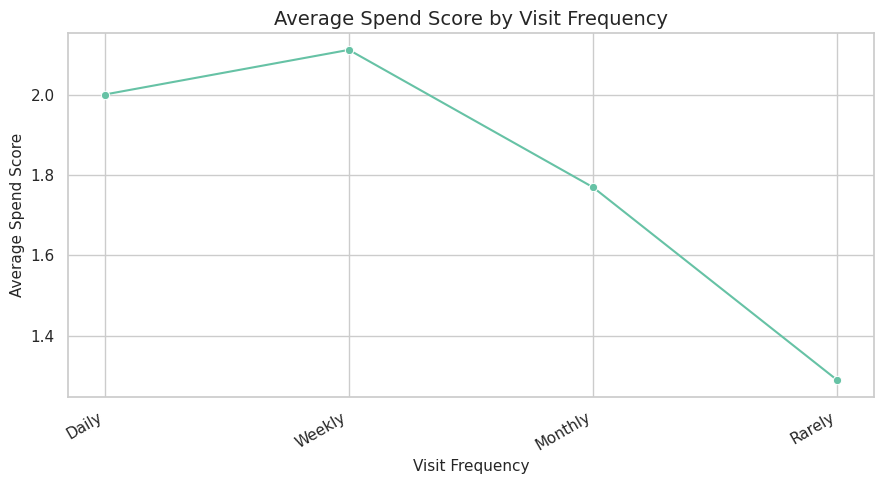

Insight: Mức chi tiêu trung bình có xu hướng cao hơn ở các nhóm khách hàng quay lại thường xuyên hơn. Nhóm Weekly và Daily có average spend score cao hơn nhóm Rarely, trong khi nhóm Rarely có mức chi tiêu trung bình thấp nhất.

Điều này cho thấy trong dataset này, tần suất ghé Starbucks và mức chi tiêu có mối liên hệ tương đối rõ. Tuy nhiên, nhóm Daily và Weekly có số lượng mẫu nhỏ, nên kết quả nên được xem là tín hiệu tham khảo thay vì kết luận tuyệt đối.



In [44]:
if has_col(df,'visitNo') and has_col(df,'spendPurchase'):
    temp=df.copy(); temp['visit_score']=make_score(temp,'visitNo'); temp['spend_score']=make_score(temp,'spendPurchase'); temp=temp.dropna(subset=['visit_score','spend_score'])
    if not temp.empty:
        spend_summary=temp.groupby(['visit_score','visit_label'], as_index=False).agg(avg_spend_score=('spend_score','mean'), customers=('spend_score','size')).sort_values('visit_score')
        display(spend_summary[['visit_label','avg_spend_score','customers']])
        plt.figure(figsize=(9,5)); ax=sns.lineplot(data=spend_summary,x='visit_label',y='avg_spend_score',marker='o', color='C0')
        ax.set_title('Average Spend Score by Visit Frequency'); ax.set_xlabel('Visit Frequency'); ax.set_ylabel('Average Spend Score')
        plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
        print("""Insight: Mức chi tiêu trung bình có xu hướng cao hơn ở các nhóm khách hàng quay lại thường xuyên hơn. Nhóm Weekly và Daily có average spend score cao hơn nhóm Rarely, trong khi nhóm Rarely có mức chi tiêu trung bình thấp nhất.

Điều này cho thấy trong dataset này, tần suất ghé Starbucks và mức chi tiêu có mối liên hệ tương đối rõ. Tuy nhiên, nhóm Daily và Weekly có số lượng mẫu nhỏ, nên kết quả nên được xem là tín hiệu tham khảo thay vì kết luận tuyệt đối.
""")

### Tổng hợp insight phần Multivariate Analysis

Từ các phân tích đa biến, có thể thấy mức chi tiêu, thời gian ở lại quán và tần suất ghé Starbucks có liên hệ đáng chú ý trong dataset này. Nhóm khách hàng quay lại thường xuyên hơn thường có average spend score cao hơn nhóm Rarely. Bên cạnh đó, khách ở lại lâu hơn, đặc biệt nhóm 1–2 giờ, cũng có tỷ lệ Frequent cao hơn nhóm chỉ ở dưới 30 phút.

Tuy nhiên, không phải biến nào cũng cho xu hướng rõ ràng. Với biến location, dữ liệu hiện tại chưa chứng minh được rằng khách ở gần cửa hàng hơn sẽ quay lại thường xuyên hơn. Nhóm 1–3km có tỷ lệ Frequent cao nhất, trong khi nhóm within 1km không nổi bật như kỳ vọng.

Nhìn chung, phần phân tích đa biến cho thấy Starbucks không chỉ nên nhìn vào tần suất ghé quán, mà cần kết hợp thêm mức chi tiêu và thời gian khách ở lại để hiểu rõ hơn về mức độ gắn bó của khách hàng. Các kết quả này vẫn nên được xem là insight ban đầu từ EDA, vì một số nhóm có số lượng mẫu nhỏ và chưa đủ cơ sở để kết luận quan hệ nhân quả.


## 9. Feature Importance Summary

Feature importance dưới đây được cập nhật theo bảng tỷ lệ thực tế. Các nhóm impact không mang nghĩa nhân quả, chỉ thể hiện pattern quan sát được trong dataset.

In [45]:
def evidence_line(col):
    table=rate_tables.get(col, pd.DataFrame())
    if table.empty: return 'No valid table available.'
    top=table.iloc[0]; bottom=table.iloc[-1]
    return f"Top `{top['group']}` = {top['frequent_rate_%']}% Frequent (n={int(top['total_customers'])}); lowest `{bottom['group']}` = {bottom['frequent_rate_%']}% (n={int(bottom['total_customers'])})."
feature_summary = pd.DataFrame([
{'feature':'spendPurchase','impact_level':'Strong / Clear pattern','evidence_from_dataset':evidence_line('spendPurchase'),'caution_note':'Pattern khá rõ, nhưng các nhóm More than RM40 và Zero có mẫu nhỏ.','business_meaning':'Spend có thể liên quan đến giá trị khách hàng và mức độ quay lại.'},
{'feature':'membershipCard','impact_level':'Strong / Clear pattern','evidence_from_dataset':'Membership Yes frequent rate = 45.0% (n=60), No = 18.87% (n=53).','caution_note':'Không kết luận membership là nguyên nhân trực tiếp làm khách quay lại.','business_meaning':'Membership có thể phản ánh mức độ gắn bó với thương hiệu.'},
{'feature':'income','impact_level':'Strong / Clear pattern','evidence_from_dataset':evidence_line('income'),'caution_note':'Nhóm thu nhập rất cao có mẫu nhỏ; RM100,000-RM150,000 chỉ n=3.','business_meaning':'Income có thể liên quan đến khả năng chi trả và tần suất quay lại.'},
{'feature':'timeSpend','impact_level':'Strong / Clear pattern','evidence_from_dataset':evidence_line('timeSpend'),'caution_note':'More than 3 hours chỉ n=1 nên không diễn giải mạnh.','business_meaning':'Thời gian ở lại có thể phản ánh engagement với không gian quán.'},
{'feature':'status','impact_level':'Strong / Clear pattern','evidence_from_dataset':evidence_line('status'),'caution_note':'Housewife chỉ n=2; trọng tâm nên là Student, Employed, Self-employed.','business_meaning':'Status giúp phân biệt bối cảnh sử dụng và nhu cầu khách hàng.'},
{'feature':'location','impact_level':'Medium / Mixed pattern','evidence_from_dataset':evidence_line('location'),'caution_note':'Pattern không nhất quán: 1km-3km cao hơn within 1km; không chứng minh khách gần hơn quay lại nhiều hơn.','business_meaning':'Location là yếu tố business hợp lý nhưng trong dataset này chỉ nên dùng hỗ trợ.'},
{'feature':'method','impact_level':'Medium / Mixed pattern','evidence_from_dataset':evidence_line('method'),'caution_note':'Drive-thru, Take away và Dine in có frequent_rate khá gần nhau.','business_meaning':'Method mô tả bối cảnh mua hàng nhưng không phải biến phân biệt mạnh.'},
{'feature':'age','impact_level':'Medium / Mixed pattern','evidence_from_dataset':evidence_line('age'),'caution_note':'Một số nhóm tuổi có mẫu nhỏ, đặc biệt 40 and above n=7.','business_meaning':'Age hỗ trợ phân đoạn thông điệp, không nên dùng độc lập.'},
{'feature':'gender','impact_level':'Low / Cautious interpretation','evidence_from_dataset':'Male frequent rate = 42.59% (n=54), Female = 23.73% (n=59).','caution_note':'Có chênh lệch trong mẫu, nhưng chưa đủ cơ sở để xem là yếu tố chính.','business_meaning':'Không nên dùng gender làm trục segmentation chính.'}])
impact_order={'Strong / Clear pattern':0,'Medium / Mixed pattern':1,'Low / Cautious interpretation':2}
feature_summary=feature_summary.assign(_order=feature_summary.impact_level.map(impact_order)).sort_values('_order').drop(columns='_order')
display(feature_summary)

,feature,impact_level,evidence_from_dataset,caution_note,business_meaning
0,spendPurchase,Strong / Clear pattern,Top `More than RM40` = 57.14% Frequent (n=7); ...,"Pattern khá rõ, nhưng các nhóm More than RM40 ...",Spend có thể liên quan đến giá trị khách hàng ...
1,membershipCard,Strong / Clear pattern,"Membership Yes frequent rate = 45.0% (n=60), N...",Không kết luận membership là nguyên nhân trực ...,Membership có thể phản ánh mức độ gắn bó với t...
2,income,Strong / Clear pattern,"Top `More than RM150,000` = 60.0% Frequent (n=...","Nhóm thu nhập rất cao có mẫu nhỏ; RM100,000-RM...",Income có thể liên quan đến khả năng chi trả v...
3,timeSpend,Strong / Clear pattern,Top `More than 3 hours` = 100.0% Frequent (n=1...,More than 3 hours chỉ n=1 nên không diễn giải ...,Thời gian ở lại có thể phản ánh engagement với...
4,status,Strong / Clear pattern,Top `Housewife` = 50.0% Frequent (n=2); lowest...,"Housewife chỉ n=2; trọng tâm nên là Student, E...",Status giúp phân biệt bối cảnh sử dụng và nhu ...
5,location,Medium / Mixed pattern,Top `1km - 3km` = 37.5% Frequent (n=32); lowes...,Pattern không nhất quán: 1km-3km cao hơn withi...,Location là yếu tố business hợp lý nhưng trong...
6,method,Medium / Mixed pattern,Top `Drive-thru` = 35.0% Frequent (n=20); lowe...,"Drive-thru, Take away và Dine in có frequent_r...",Method mô tả bối cảnh mua hàng nhưng không phả...
7,age,Medium / Mixed pattern,Top `40 and above` = 57.14% Frequent (n=7); lo...,"Một số nhóm tuổi có mẫu nhỏ, đặc biệt 40 and a...","Age hỗ trợ phân đoạn thông điệp, không nên dùn..."
8,gender,Low / Cautious interpretation,"Male frequent rate = 42.59% (n=54), Female = 2...","Có chênh lệch trong mẫu, nhưng chưa đủ cơ sở đ...",Không nên dùng gender làm trục segmentation ch...


## 9.1 Deep Dive: Student, Employed and Self-employed Customers

Phần này kiểm chứng riêng 3 nhóm `Student`, `Employed`, `Self-employed`. Insight chỉ dựa trên số lượng, frequent_rate, income/spend/membership/time/location thực tế của từng nhóm.

In [46]:
focus_status=['Student','Employed','Self-employed']
deep_df=df[df.get('status_label',pd.Series(index=df.index,dtype='object')).isin(focus_status)].copy() if not df.empty else pd.DataFrame()
def dominant(sub, lab):
    if lab not in sub.columns or sub.empty: return 'N/A'
    vc=sub[lab].value_counts(dropna=False)
    return f'{vc.index[0]} ({vc.iloc[0]/len(sub)*100:.1f}%, n={vc.iloc[0]})' if not vc.empty else 'N/A'
def yes_rate(sub):
    if 'membership_label' not in sub.columns or sub.empty: return np.nan
    return round((sub['membership_label'].eq('Yes').mean()*100),2)
rows=[]
for s in focus_status:
    sub=deep_df[deep_df['status_label'].eq(s)] if not deep_df.empty else pd.DataFrame()
    total=len(sub); freq=int(sub['return_group'].eq('Frequent').sum()) if total else 0; inf=int(sub['return_group'].eq('Infrequent').sum()) if total else 0
    rows.append({'status_group':s,'total_customers':total,'frequent_customers':freq,'infrequent_customers':inf,'frequent_rate_%':round(freq/total*100,2) if total else 0,'dominant_income_group':dominant(sub,'income_label'),'dominant_spend_group':dominant(sub,'spend_label'),'membership_yes_rate_%':yes_rate(sub),'dominant_timeSpend_group':dominant(sub,'time_label'),'dominant_location_group':dominant(sub,'location_label')})
status_deep_summary=pd.DataFrame(rows)
display(status_deep_summary)

,status_group,total_customers,frequent_customers,infrequent_customers,frequent_rate_%,dominant_income_group,dominant_spend_group,membership_yes_rate_%,dominant_timeSpend_group,dominant_location_group
0,Student,37,7,30,18.92,"Less than RM25,000 (97.3%, n=36)","Less than RM20 (67.6%, n=25)",32.43,"Below 30 minutes (59.5%, n=22)","more than 3km (62.2%, n=23)"
1,Employed,58,22,36,37.93,"Less than RM25,000 (41.4%, n=24)","Around RM20 - RM40 (50.0%, n=29)",63.79,"Below 30 minutes (55.2%, n=32)","more than 3km (37.9%, n=22)"
2,Self-employed,16,7,9,43.75,"RM50,000 - RM100,000 (25.0%, n=4)","Less than RM20 (37.5%, n=6)",62.50,"Below 30 minutes (50.0%, n=8)","more than 3km (56.2%, n=9)"


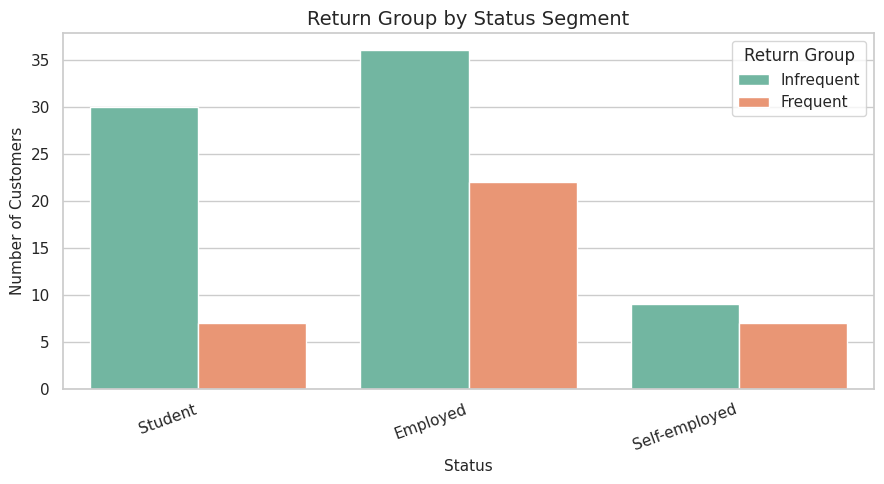

Insight: Employed là nhóm lớn nhất (58 khách) và có frequent_rate 37.93%; Student có 37 khách nhưng frequent_rate 18.92%; Self-employed có frequent_rate 43.75% nhưng chỉ có 16 khách nên cần diễn giải thận trọng.


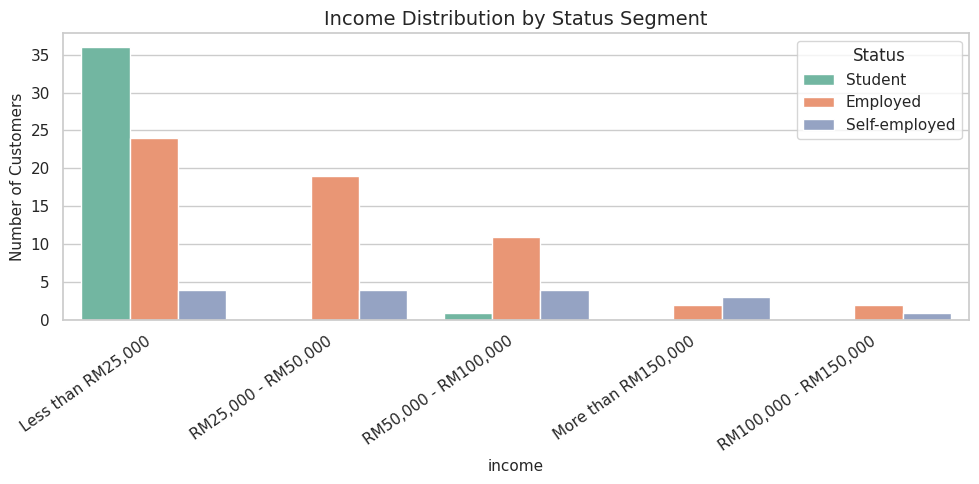

Insight: Student chủ yếu thuộc nhóm Less than RM25,000, trong khi Employed và Self-employed phân tán hơn. Điều này ủng hộ hướng ưu đãi giá mềm cho Student, nhưng các nhóm thu nhập cao vẫn có mẫu nhỏ.


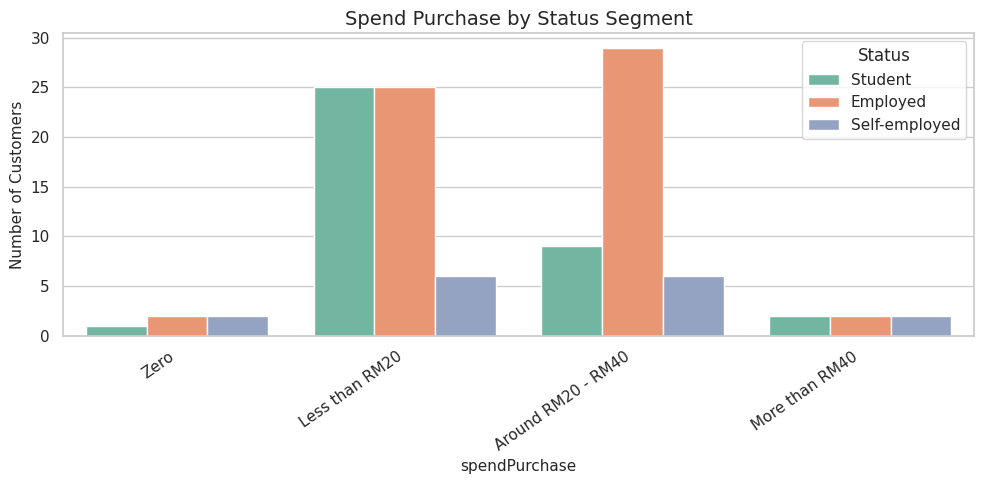

Insight: Student tập trung nhiều ở Less than RM20; Employed có nhiều khách ở RM20-40 hơn. Self-employed không vượt trội hoàn toàn về spend nên không nên gọi chắc là high-value.


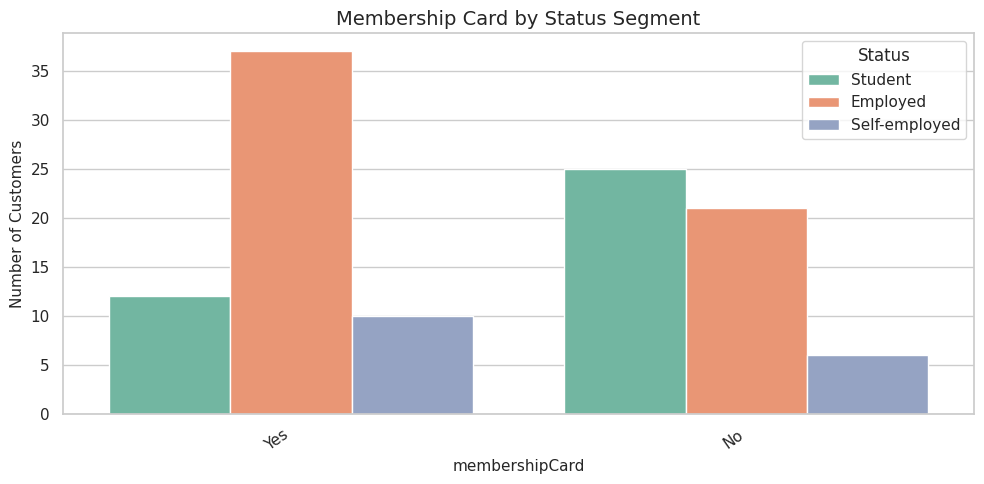

Insight: Employed và Self-employed có membership yes rate cao hơn Student trong dataset này. Đây là tín hiệu về engagement, không phải bằng chứng nhân quả.


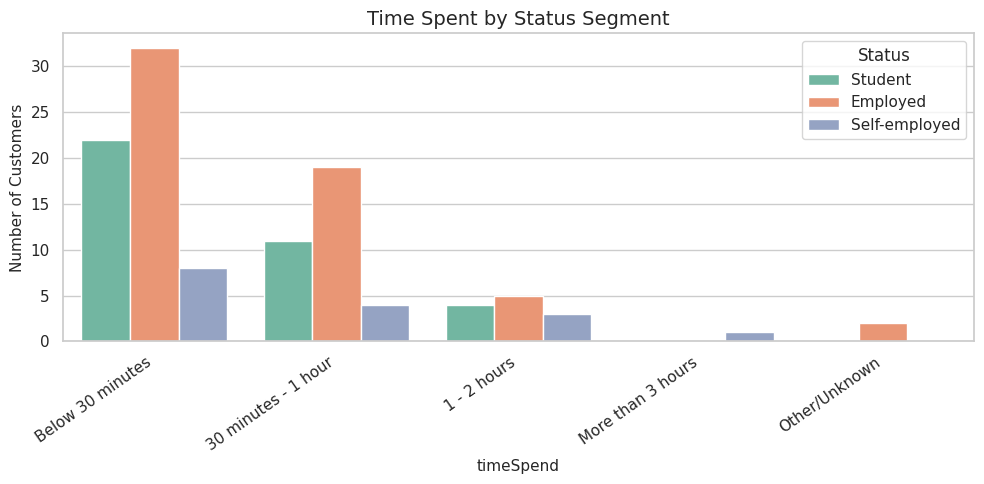

Insight: Cả ba nhóm vẫn có nhiều khách ở lại dưới 30 phút. Self-employed có một phần ở lại lâu hơn, nhưng mẫu nhỏ nên chỉ xem là tín hiệu tiềm năng engagement.


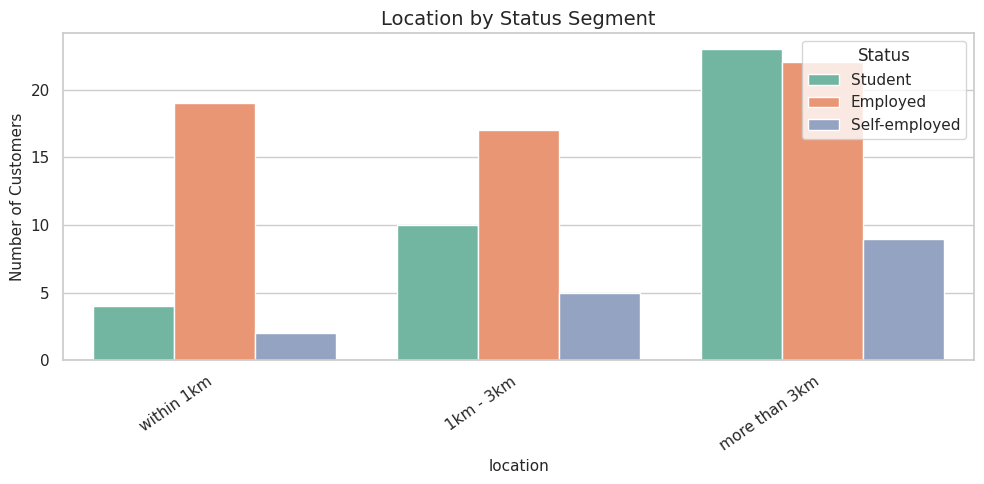

Insight: Student và Self-employed trong mẫu này tập trung nhiều ở more than 3km. Location không ủng hộ kết luận đơn giản rằng gần cửa hàng hơn thì quay lại thường xuyên hơn.


In [47]:
def deep_count(col, title, insight):
    lab=get_label_col(col)
    if deep_df.empty or lab not in deep_df.columns: print(f'Skip `{col}` deep chart.'); return
    plt.figure(figsize=(10,5)); ax=sns.countplot(data=deep_df,x=lab,hue='status_label',order=label_order(deep_df,col),palette='Set2')
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel('Number of Customers'); ax.legend(title='Status')
    plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show(); print('Insight:', insight)
if not deep_df.empty:
    plt.figure(figsize=(9,5)); ax=sns.countplot(data=deep_df,x='status_label',hue='return_group',order=focus_status,palette='Set2')
    ax.set_title('Return Group by Status Segment'); ax.set_xlabel('Status'); ax.set_ylabel('Number of Customers'); ax.legend(title='Return Group')
    plt.xticks(rotation=20,ha='right'); plt.tight_layout(); plt.show()
    print('Insight: Employed là nhóm lớn nhất (58 khách) và có frequent_rate 37.93%; Student có 37 khách nhưng frequent_rate 18.92%; Self-employed có frequent_rate 43.75% nhưng chỉ có 16 khách nên cần diễn giải thận trọng.')
deep_count('income','Income Distribution by Status Segment','Student chủ yếu thuộc nhóm Less than RM25,000, trong khi Employed và Self-employed phân tán hơn. Điều này ủng hộ hướng ưu đãi giá mềm cho Student, nhưng các nhóm thu nhập cao vẫn có mẫu nhỏ.')
deep_count('spendPurchase','Spend Purchase by Status Segment','Student tập trung nhiều ở Less than RM20; Employed có nhiều khách ở RM20-40 hơn. Self-employed không vượt trội hoàn toàn về spend nên không nên gọi chắc là high-value.')
deep_count('membershipCard','Membership Card by Status Segment','Employed và Self-employed có membership yes rate cao hơn Student trong dataset này. Đây là tín hiệu về engagement, không phải bằng chứng nhân quả.')
deep_count('timeSpend','Time Spent by Status Segment','Cả ba nhóm vẫn có nhiều khách ở lại dưới 30 phút. Self-employed có một phần ở lại lâu hơn, nhưng mẫu nhỏ nên chỉ xem là tín hiệu tiềm năng engagement.')
deep_count('location','Location by Status Segment','Student và Self-employed trong mẫu này tập trung nhiều ở more than 3km. Location không ủng hộ kết luận đơn giản rằng gần cửa hàng hơn thì quay lại thường xuyên hơn.')

In [48]:
status_segment_summary = pd.DataFrame([
{'status_group':'Student','main_behavior':'37 khách, frequent_rate 18.92%; income chủ yếu Less than RM25,000 và spend chủ yếu Less than RM20.','business_value':'Tiềm năng dài hạn, nhưng hiện tại return rate chưa cao trong dataset này.','recommended_strategy':'Student combo, low-price bundle, campus campaign, entry-level loyalty benefits.'},
{'status_group':'Employed','main_behavior':'58 khách, frequent_rate 37.93%; membership yes rate 63.8% và spend RM20-40 chiếm 50.0%.','business_value':'Nhóm lớn và có hành vi ổn định hơn Student trong dataset này.','recommended_strategy':'Morning/lunch combo, membership reward, personalized offer.'},
{'status_group':'Self-employed','main_behavior':'16 khách, frequent_rate 43.75%; membership yes rate 62.5%, spend không vượt trội hoàn toàn.','business_value':'Nhóm đáng chú ý về engagement, nhưng mẫu nhỏ nên không gọi chắc là high-value.','recommended_strategy':'Workspace-friendly offer, meeting combo, WiFi/seat comfort, loyalty for repeat visits.'}])
display(status_segment_summary)

,status_group,main_behavior,business_value,recommended_strategy
0,Student,"37 khách, frequent_rate 18.92%; income chủ yếu...","Tiềm năng dài hạn, nhưng hiện tại return rate ...","Student combo, low-price bundle, campus campai..."
1,Employed,"58 khách, frequent_rate 37.93%; membership yes...",Nhóm lớn và có hành vi ổn định hơn Student tro...,"Morning/lunch combo, membership reward, person..."
2,Self-employed,"16 khách, frequent_rate 43.75%; membership yes...","Nhóm đáng chú ý về engagement, nhưng mẫu nhỏ n...","Workspace-friendly offer, meeting combo, WiFi/..."


## 10. Customer Segmentation

Segmentation dưới đây dùng bảng tỷ lệ và profile thực tế, tránh kết luận quá mạnh với biến có pattern chưa rõ như location hoặc biến mẫu nhỏ.

In [49]:
profile_df=df[df['return_group'].isin(['Frequent','Infrequent'])].copy() if 'return_group' in df.columns else pd.DataFrame()
if profile_df.empty:
    print('No Frequent/Infrequent data available.')
else:
    for col in ['income','timeSpend','location','spendPurchase','membershipCard']:
        profile_df[col+'_score']=make_score(profile_df,col)
    profile_table=profile_df.groupby('return_group').agg(number_of_customers=('return_group','size'),avg_income_score=('income_score','mean'),avg_timeSpend_score=('timeSpend_score','mean'),avg_location_score=('location_score','mean'),avg_spendPurchase_score=('spendPurchase_score','mean'),membership_rate=('membershipCard_score','mean')).round(2)
    display(profile_table)
    print('Insight: Frequent customers trong dataset này có xu hướng rõ hơn ở spendPurchase cao hơn và membership rate cao hơn. Location score không nên đọc như bằng chứng rằng càng gần càng frequent hơn.')
    for col in ['status','income','membershipCard']:
        lab=get_label_col(col)
        if lab in profile_df.columns:
            display(pd.crosstab(profile_df[lab], profile_df['return_group'], margins=True))
            print(f'Insight: Crosstab `{col}` hỗ trợ segmentation, nhưng cần đọc cùng total_customers và frequent_rate để tránh kết luận quá mạnh với nhóm nhỏ.')

,number_of_customers,avg_income_score,avg_timeSpend_score,avg_location_score,avg_spendPurchase_score,membership_rate
return_group,,,,,,
Frequent,37,1.05,0.92,1.30,1.86,0.73
Infrequent,76,0.62,0.47,1.26,1.29,0.43


Insight: Frequent customers trong dataset này có xu hướng rõ hơn ở spendPurchase cao hơn và membership rate cao hơn. Location score không nên đọc như bằng chứng rằng càng gần càng frequent hơn.


return_group,Frequent,Infrequent,All
status_label,,,
Employed,22,36,58
Housewife,1,1,2
Self-employed,7,9,16
Student,7,30,37
All,37,76,113


Insight: Crosstab `status` hỗ trợ segmentation, nhưng cần đọc cùng total_customers và frequent_rate để tránh kết luận quá mạnh với nhóm nhỏ.


return_group,Frequent,Infrequent,All
income_label,,,
"Less than RM25,000",16,49,65
"More than RM150,000",3,2,5
"RM100,000 - RM150,000",0,3,3
"RM25,000 - RM50,000",9,14,23
"RM50,000 - RM100,000",9,8,17
All,37,76,113


Insight: Crosstab `income` hỗ trợ segmentation, nhưng cần đọc cùng total_customers và frequent_rate để tránh kết luận quá mạnh với nhóm nhỏ.


return_group,Frequent,Infrequent,All
membership_label,,,
No,10,43,53
Yes,27,33,60
All,37,76,113


Insight: Crosstab `membershipCard` hỗ trợ segmentation, nhưng cần đọc cùng total_customers và frequent_rate để tránh kết luận quá mạnh với nhóm nhỏ.


**Segmentation insight đã kiểm chứng:**  
Trong dataset này, Frequent customers có xu hướng xuất hiện nhiều hơn ở các nhóm có `spendPurchase` cao hơn, có `membershipCard`, một số nhóm thu nhập trung bình/cao hơn, và các nhóm nghề nghiệp như Employed/Self-employed. Infrequent customers tập trung nhiều hơn ở nhóm chi tiêu thấp, không có membership card, thu nhập thấp hơn và Student.

Location chưa cho thấy pattern nhất quán: nhóm 1km-3km có frequent_rate cao hơn within 1km, nên không nên dùng location như bằng chứng mạnh. Gender có chênh lệch trong mẫu nhưng không nên dùng làm yếu tố phân nhóm chính.

## 11. Business Recommendations

### Student Strategy

**Evidence:** Student có 37 khách, frequent_rate 18.92%, income chủ yếu Less than RM25,000 và spend chủ yếu Less than RM20. Đây là nhóm đáng kể nhưng return rate hiện tại chưa cao.

**Actions:** Student combo, low-price bundle, campus campaign, entry-level loyalty benefits.

### Employed Strategy

**Evidence:** Employed là nhóm lớn nhất với 58 khách, frequent_rate 37.93%, membership yes rate 63.8% và spend RM20-40 chiếm 50.0%.

**Actions:** Morning/lunch combo, membership reward, personalized offer, ưu đãi cho khách quay lại hằng tuần/hằng tháng.

### Self-employed Strategy

**Evidence:** Self-employed có frequent_rate 43.75% nhưng chỉ có 16 khách; membership yes rate 62.5%, spend không vượt trội hoàn toàn. Vì vậy nên xem đây là nhóm có tiềm năng engagement, chưa nên gọi chắc là high-value.

**Actions:** Workspace-friendly offer, meeting combo, WiFi/seat comfort, loyalty for repeat visits.

### Membership Strategy

**Evidence:** Membership Yes frequent rate = 45.0%, No = 18.87%. Pattern này khá rõ trong dataset nhưng không chứng minh quan hệ nhân quả.

**Actions:** Reward points, monthly challenge, personalized member promotion.

### Spending Strategy

**Evidence:** Nhóm RM20-40 có frequent_rate 53.33%, More than RM40 là 57.14% nhưng n=7, trong khi Less than RM20 là 16.07%.

**Actions:** Upsell combo, bundle RM20-40, reward for repeat purchase.

### Location-based Test

**Evidence:** Location chưa thật sự nhất quán: 1km-3km có frequent_rate 37.5%, more than 3km là 32.14%, within 1km là 28.0%.

**Actions:** Có thể thử nghiệm local promotion, nhưng không nên xem location là insight mạnh trong dataset này.

## 12. Conclusion

Qua quá trình phân tích bộ dữ liệu khảo sát khách hàng Starbucks, có thể thấy hành vi quay lại của khách hàng không chỉ liên quan đến tần suất mua đồ uống, mà còn gắn với nhiều yếu tố khác như mức chi tiêu, thẻ thành viên, thu nhập, thời gian ở lại quán và nghề nghiệp.

Trong dataset này, nhóm khách hàng quay lại thường xuyên hơn thường có xu hướng chi tiêu ở mức trung bình đến cao, có membership card và ở lại quán lâu hơn. Điều này cho thấy Starbucks không chỉ được khách hàng sử dụng như một nơi mua cà phê nhanh, mà còn là không gian để học tập, làm việc, gặp gỡ hoặc dành thời gian cá nhân. Vì vậy, những khách hàng có mức độ gắn bó cao hơn với trải nghiệm tại quán cũng có khả năng quay lại đều hơn.

Xét theo nhóm nghề nghiệp, Employed là nhóm có số lượng lớn nhất và có hành vi quay lại tương đối ổn định. Student cũng là một nhóm đáng chú ý, nhưng tỷ lệ Frequent chưa cao, có thể do bị giới hạn bởi thu nhập và mức chi tiêu. Trong khi đó, Self-employed có tỷ lệ Frequent khá tốt trong dataset này, nhưng số lượng mẫu còn nhỏ nên chỉ nên xem đây là nhóm có tiềm năng gắn bó, chưa thể kết luận chắc chắn là nhóm khách hàng giá trị cao nhất.

Một điểm đáng chú ý là không phải biến nào cũng cho kết quả đúng như kỳ vọng ban đầu. Ví dụ, location chưa thể hiện rõ rằng khách ở gần cửa hàng hơn sẽ quay lại thường xuyên hơn. Do đó, các insight trong bài nên được hiểu là kết quả khám phá ban đầu từ EDA, không phải bằng chứng về quan hệ nhân quả.

Từ các kết quả trên, Starbucks có thể tập trung vào ba hướng chính: tăng hiệu quả membership card, xây dựng ưu đãi phù hợp cho từng nhóm khách hàng, và cải thiện trải nghiệm tại quán để khuyến khích khách hàng quay lại nhiều hơn. Đặc biệt, nhóm Student cần các gói ưu đãi dễ tiếp cận hơn, nhóm Employed phù hợp với chương trình tích điểm và ưu đãi định kỳ, còn nhóm Self-employed có thể được khai thác thông qua các lợi ích liên quan đến không gian làm việc, gặp gỡ và sử dụng quán trong thời gian dài.

Tuy nhiên, phân tích này vẫn có một số hạn chế. Bộ dữ liệu có quy mô nhỏ và được thu thập từ khảo sát, nên kết quả có thể bị ảnh hưởng bởi sai lệch mẫu hoặc cách người tham gia trả lời. Vì vậy, để có kết luận chắc chắn hơn, cần thêm dữ liệu lớn hơn và có thể kết hợp với các phương pháp mô hình hóa dự đoán trong các bước nghiên cứu tiếp theo.